### Install varseek, and import all packages

In [1]:
try:
    import varseek as vk
except ImportError:
    print("varseek not found, installing...")
    !pip install -U -q varseek

In [2]:
import os
import re
import anndata as ad
import pandas as pd
import pysam

import varseek as vk

# [vk denovo](https://github.com/pachterlab/varseek) on NA12878 (GIAB HG001) — benchmarked against ground truth

This notebook runs the **varseek de novo** pipeline (`vk denovo` → `vk ref` → `vk count`) on
**NA12878 / HG001** whole-genome sequencing reads, then compares the calls **directly to the
Genome in a Bottle (GIAB) HG001 v4.2.1 truth set** with `hap.py` — the standard germline
small-variant benchmarking tool.

**Scope: chromosome 20** (the canonical GIAB benchmarking chromosome), in the GIAB
high-confidence regions. This keeps the demo tractable while giving a real ground-truth
comparison.

**Data**
- Reads: GIAB NIST `RMNISTHS_30xdownsample.bam` (NA12878, ~30×), chr20 reads only, re-aligned to GRCh38.
- Reference: Ensembl GRCh38 primary assembly (already used by `vk_denovo.ipynb`).
- Truth: `HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz` + high-confidence `.bed`, restricted to chr20
  and renamed to Ensembl contig naming (`chr20` → `20`).

> Because the input is whole-genome **DNA** (not RNA), `vk denovo` aligns with **bowtie2**
> (DNA aligner) rather than STAR, and `vk count` runs in `bulk`/`paired` mode.


### Define paths and parameters

In [3]:
import os, re, gzip, subprocess
import numpy as np
import pandas as pd
import anndata as ad
import pysam

# ---- reference (shared with vk_denovo.ipynb) ----
reference_dir = os.path.join("data", "reference")
sequences = os.path.join(reference_dir, "ensembl_grch38_release114", "Homo_sapiens.GRCh38.dna.primary_assembly.fa")
gtf = os.path.join(reference_dir, "ensembl_grch38_release114", "Homo_sapiens.GRCh38.114.gtf")

# ---- NA12878 chr20 working dir ----
root = os.path.join("data", "na12878_chr20")
reads_dir = os.path.join(root, "reads")
r1 = os.path.join(reads_dir, "NA12878_chr20_R1.fastq.gz")
r2 = os.path.join(reads_dir, "NA12878_chr20_R2.fastq.gz")
chr20_bam = os.path.join(reads_dir, "chr20.bam")

bowtie2_index_prefix = os.path.join(reference_dir, "bowtie2_chr20", "chr20")

# vk denovo out
variants_dir = os.path.join(root, "varseek_denovo_out")
variants_vcf = os.path.join(variants_dir, "variants.vcf.gz")
variants = os.path.join(variants_dir, "variants.tsv")
denovo_bam_dir = os.path.join(variants_dir, "bams")

# vk ref out
vk_ref_out_dir = os.path.join(root, "varseek_ref_out")
vcrs_index = os.path.join(vk_ref_out_dir, "vcrs_index_denovo.idx")
vcrs_t2g = os.path.join(vk_ref_out_dir, "vcrs_t2g_denovo.txt")

# vk count out
vk_count_out_dir = os.path.join(root, "varseek_count_out")
vk_count_variants_vcf = os.path.join(vk_count_out_dir, "varseek_variants.vcf")

# GIAB truth
giab_dir = os.path.join(root, "giab")
truth_vcf = os.path.join(giab_dir, "truth_chr20_ens.vcf.gz")
confident_bed = os.path.join(giab_dir, "confident_chr20_ens.bed")

# hap.py out
happy_out = os.path.join(root, "happy_output")

# general parameters
w = 37
k = 41
min_counts_denovo = 3
min_counts_clean = 1
threads = 16
read_length = 148


In [4]:
# --- Tool runtime recording -------------------------------------------------
# Every tool below (vk denovo / vk ref / vk count / DeepVariant / GATK
# HaplotypeCaller / GATK Mutect2) is timed, and its wall-clock runtime in
# seconds is written to `tool_runtimes.json` *immediately* after it finishes.
# Persisting to disk means a recorded time is not forgotten across kernel
# restarts, and is not lost when a later cell re-runs and skips the tool via an
# `if not os.path.exists(...)` guard (in that case the previously recorded time
# is simply kept). The three varseek stages are stored separately here for
# reference; the runtime plot at the end sums them into one "varseek" bar.
import json, time
from contextlib import contextmanager

runtime_json = os.path.join(root, "tool_runtimes.json")

def load_runtimes():
    if os.path.exists(runtime_json):
        with open(runtime_json) as fh:
            return json.load(fh)
    return {}

def save_runtime(name, seconds):
    data = load_runtimes()
    data[name] = seconds
    os.makedirs(os.path.dirname(runtime_json), exist_ok=True)
    with open(runtime_json, "w") as fh:
        json.dump(data, fh, indent=2, sort_keys=True)
    print(f"[runtime] {name}: {seconds:.1f} s ({seconds/60:.2f} min)  ->  {runtime_json}")

@contextmanager
def record_runtime(name):
    _t0 = time.perf_counter()
    try:
        yield
    finally:
        save_runtime(name, time.perf_counter() - _t0)

print(f"Runtimes will be written to: {runtime_json}")
print("Existing recorded runtimes:", load_runtimes())

Runtimes will be written to: data/na12878_chr20/tool_runtimes.json
Existing recorded runtimes: {'deepvariant': 941.5780808329582, 'haplotypecaller': 1727.4541525095701, 'mutect2': 1306.6620010212064, 'vk count': 0.007767230272293091, 'vk denovo': 1009.8870076946914, 'vk ref': 99.32087076455355}


In [5]:
if not os.path.exists(sequences):
    sequences_dir = os.path.dirname(sequences)
    !gget ref -w dna -r 114 --out_dir {sequences_dir} -d human
    !gunzip {sequences}.gz

if not os.path.exists(gtf):
    gtf_dir = os.path.dirname(gtf)
    !gget ref -w gtf -r 114 --out_dir {gtf_dir} -d human
    !gunzip {gtf}.gz

### Download NA12878 chr20 reads (GIAB 30× BAM) and re-align target

We stream only the **chr20** reads from the GIAB NIST 30× downsampled NA12878 BAM, then convert
them to paired FASTQ. Reads are reference-agnostic, so although that BAM is GRCh37-aligned we
re-align to GRCh38 below.

In [6]:
GIAB_30X_BAM = ("https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/data/NA12878/"
                "NIST_NA12878_HG001_HiSeq_300x/RMNISTHS_30xdownsample.bam")

os.makedirs(reads_dir, exist_ok=True)
if not (os.path.exists(r1) and os.path.exists(r2)):
    if not os.path.exists(chr20_bam):
        subprocess.run(["samtools", "view", "-@", str(threads), "-b", GIAB_30X_BAM, "20",
                        "-o", chr20_bam], check=True)
    # collate into read pairs, then emit paired FASTQ (singletons dropped)
    collate = subprocess.Popen(["samtools", "collate", "-@", str(threads), "-u", "-O",
                                chr20_bam, os.path.join(reads_dir, "collate_tmp")],
                               stdout=subprocess.PIPE)
    subprocess.run(["samtools", "fastq", "-@", str(threads), "-1", r1, "-2", r2,
                    "-0", "/dev/null", "-s", os.path.join(reads_dir, "singletons.fastq.gz"),
                    "-n", "-"], stdin=collate.stdout, check=True)
    collate.wait()

n_pairs = sum(1 for _ in gzip.open(r1, "rt")) // 4
print(f"NA12878 chr20 read pairs: {n_pairs:,}")


NA12878 chr20 read pairs: 6,633,667


### Build a chr20 bowtie2 index

`vk denovo` aligns DNA reads with bowtie2. The reads were extracted from chr20, so a chr20 index
suffices and is fast to build.

In [7]:
bt2_dir = os.path.dirname(bowtie2_index_prefix)
os.makedirs(bt2_dir, exist_ok=True)
if not os.path.exists(bowtie2_index_prefix + ".1.bt2"):
    chr20_fa = bowtie2_index_prefix + ".fa"
    subprocess.run(f"samtools faidx {sequences} 20 > {chr20_fa}", shell=True, check=True)
    subprocess.run(["bowtie2-build", "--threads", str(threads), chr20_fa, bowtie2_index_prefix],
                   check=True)
print("bowtie2 chr20 index ready:", bowtie2_index_prefix)


bowtie2 chr20 index ready: data/reference/bowtie2_chr20/chr20


### Prepare the GIAB ground-truth VCF and high-confidence BED (chr20, Ensembl naming)

The GIAB truth uses UCSC contig names (`chr20`); our reference uses Ensembl naming (`20`). We
subset to chr20, rename, and left-normalize the truth against the reference. The high-confidence
BED defines where the benchmark is valid — both `vk denovo` calling and `hap.py` evaluation are
restricted to it.

In [8]:
os.makedirs(giab_dir, exist_ok=True)
GIAB_REL = ("https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/release/"
            "NA12878_HG001/NISTv4.2.1/GRCh38")
raw_vcf = os.path.join(giab_dir, "HG001_GRCh38_v4.2.1_benchmark.vcf.gz")
raw_bed = os.path.join(giab_dir, "HG001_GRCh38_v4.2.1_benchmark.bed")

if not os.path.exists(truth_vcf):
    if not os.path.exists(raw_vcf):
        subprocess.run(["curl", "-sL", "-o", raw_vcf,
                        f"{GIAB_REL}/HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz"], check=True)
        subprocess.run(["curl", "-sL", "-o", raw_vcf + ".tbi",
                        f"{GIAB_REL}/HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz.tbi"], check=True)
    rename = os.path.join(giab_dir, "rename_chr20.txt")
    with open(rename, "w") as fh:
        fh.write("chr20\t20\n")
    p1 = subprocess.Popen(["bcftools", "view", "-r", "chr20", raw_vcf, "-Ou"], stdout=subprocess.PIPE)
    p2 = subprocess.Popen(["bcftools", "annotate", "--rename-chrs", rename, "-Ou"],
                          stdin=p1.stdout, stdout=subprocess.PIPE); p1.stdout.close()
    subprocess.run(["bcftools", "norm", "-f", sequences, "-m", "-both", "-Oz", "-o", truth_vcf],
                   stdin=p2.stdout, check=True); p2.stdout.close(); p1.wait(); p2.wait()
    subprocess.run(["bcftools", "index", "-t", "-f", truth_vcf], check=True)

if not os.path.exists(confident_bed):
    if not os.path.exists(raw_bed):
        subprocess.run(["curl", "-sL", "-o", raw_bed,
                        f"{GIAB_REL}/HG001_GRCh38_1_22_v4.2.1_benchmark.bed"], check=True)
    subprocess.run("awk -F'\t' '$1==\"chr20\"{sub(/^chr/,\"\",$1);print}' OFS='\t' "
                   f"{raw_bed} > {confident_bed}", shell=True, check=True)

print("truth variants (chr20):", subprocess.run(["bcftools", "view", "-H", truth_vcf],
      capture_output=True, text=True).stdout.count("\n"))
print("confident intervals (chr20):", sum(1 for _ in open(confident_bed)))


truth variants (chr20): 83629
confident intervals (chr20): 13529


### Run `vk denovo`

Align the reads (bowtie2) and call de novo variants (bcftools), restricting calling to the GIAB
high-confidence regions.

In [9]:
if not os.path.exists(variants):
    with record_runtime("vk denovo"):
        vk.denovo(
            inputs=[r1, r2],
            sequences=sequences,
            parity="paired",
            aligner="bowtie2",
            bowtie2_genome_index_prefix=bowtie2_index_prefix,
            out_bam_dir=denovo_bam_dir,
            regions=confident_bed,
            output=variants_vcf,
            output_tsv=variants,
            min_counts=min_counts_denovo,
            read_length=read_length,
            threads=threads,
            verbose=1,
            technology="dna"
        )

variants_df = pd.read_csv(variants, sep="\t")
print(f"Number of de novo variants: {len(variants_df):,}")
variants_df.head()

Number of de novo variants: 80,438


,seq_id,variant
0,20,g.82603A>C
1,20,g.83158C>T
2,20,g.85259G>A
3,20,g.85729G>A
4,20,g.86079C>A


### Run `vk ref`

In [10]:
vcrs_unfiltered_fasta_out = os.path.join(vk_ref_out_dir, "vcrs_unfiltered.fa")
if not os.path.exists(vcrs_index):
    with record_runtime("vk ref"):
        vk.ref(
            variants=variants,
            sequences=sequences,
            seq_id_column="seq_id",
            var_column="variant",
            remove_alignment_to_reference=False,
            out=vk_ref_out_dir,
            reference_out_dir=reference_dir,
            vcrs_unfiltered_fasta_out=vcrs_unfiltered_fasta_out,
            save_variants_updated_dataframe=True,
            index_out=vcrs_index,
            vcrs_t2g_out=vcrs_t2g,
            w=w,
            k=k,
        )
print("VCRS index:", vcrs_index)

18:04:16 - INFO - Using COSMIC email from COSMIC_EMAIL environment variable
18:04:16 - INFO - Using COSMIC password from COSMIC_PASSWORD environment variable
18:04:39 - INFO - add_gene_name_to_header is set, but no GTF path was provided; leaving headers without gene-name annotations.
18:04:39 - INFO - Using the seq_id_column:var_column 'seq_id:variant' columns as the variant header column.
18:04:40 - INFO - Removing 0 duplications > k
18:04:42 - INFO - Unfiltered (pre-filter, pre-merge) VCRS fasta written to data/na12878_chr20/varseek_ref_out/vcrs_unfiltered.fa.
/home/jrich/Desktop/varseek-fresh/varseek/varseek_build.py:1257: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutations["vcrs_sequence_kmer_length"] = mutations["vcrs_sequence"].apply(la

[runtime] vk ref: 99.1 s (1.65 min)  ->  data/na12878_chr20/tool_runtimes.json
VCRS index: data/na12878_chr20/varseek_ref_out/vcrs_index_denovo.idx


### Run `vk count`

Pseudoalign the reads against the variant reference and threshold to produce the varseek variant
call set. Bulk paired-end mode (no cell barcodes).

In [11]:
with record_runtime("vk count"):
    vk_count_output_dict = vk.count(
        [r1, r2],
        index=vcrs_index,
        t2g=vcrs_t2g,
        technology="dna",
        parity="paired",
        out=vk_count_out_dir,
        k=k,
        threads=threads,
        strand="unstranded",
        min_counts=min_counts_clean,
    )
adata_path = vk_count_output_dict["adata_path"]
print("adata:", adata_path)

18:05:55 - INFO - parity='paired' and parity_kb_count='single'. This means that kb count will run in single-end mode on this paired-end data, which will enable different pairs to be processed independently and thus potentially detect different variants. To turn this feature off, set parity_kb_count='paired'.
18:05:55 - INFO - Error sorting fastq files: File data/na12878_chr20/reads/NA12878_chr20_R1.fastq.gz does not match the expected bulk file naming convention of SAMPLE_PAIR.EXT where SAMPLE is sample name, PAIR is 1/2, and EXT is a fastq extension - or the Illumina file naming convention of SAMPLE_LANE_R[12]_001.fastq.gz, where SAMPLE is letters, numbers, underscores; LANE is numbers with optional leading 0s; pair is either R1 or R2; and it has .fq or .fastq extension (or .fq.gz or .fastq.gz).
Raising exception and exiting because sort_fastqs=True, which requires standard bulk or Illumina file naming convention. Please check fastq file names or set sort_fastqs=False.. Returning unso

[runtime] vk count: 73.5 s (1.22 min)  ->  data/na12878_chr20/tool_runtimes.json
adata: /home/jrich/Desktop/varseek-examples/data/na12878_chr20/varseek_count_out/adata_cleaned.h5ad


Convert the varseek AnnData call matrix to a sites-only VCF (same helper as `vk_denovo.ipynb`).

In [12]:
def adata_to_vcf(adata, vcf_out):
    if os.path.exists(vcf_out):
        print(f"{vcf_out} already exists, skipping VCF writing.")
        return
    if isinstance(adata, str):
        adata = ad.read_h5ad(adata)
    adata = adata[:, adata.X.sum(axis=0) > 0]  # keep variants present in >=1 sample
    variants = adata.var_names.tolist()
    fasta = pysam.FastaFile(sequences)
    chromosomes = {str(i) for i in range(1, 23)}.union({"X", "Y", "MT"})

    var_series = pd.Series(variants, dtype="object").str.split(";").explode()
    var_series = var_series[var_series.str.len() > 0].reset_index(drop=True)
    snv = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)(?P<REF>[ACGT]+)>(?P<ALT>[ACGT]+)$")
    ins = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)_(?P<END>\d+)ins(?P<INS>[ACGT]+)$")
    dele = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<START>\d+)(?:_(?P<END>\d+))?del(?P<DEL>[ACGT]*)$")
    snv_mask, ins_mask, del_mask = snv["CHROM"].notna(), ins["CHROM"].notna(), dele["START"].notna()
    for var in var_series[~(snv_mask | ins_mask | del_mask)]:
        print(f"Could not parse: {var}")

    frames = []
    snv = snv[snv_mask & snv["CHROM"].isin(chromosomes)]
    if not snv.empty:
        frames.append(pd.DataFrame({"CHROM": snv["CHROM"], "POS": snv["POS"].astype(int),
                                    "REF": snv["REF"], "ALT": snv["ALT"]}, index=snv.index))
    ins = ins[ins_mask & ins["CHROM"].isin(chromosomes)]
    if not ins.empty:
        ins_pos = ins["POS"].astype(int)
        anchor = pd.Series([fasta.fetch(c, p - 1, p) for c, p in zip(ins["CHROM"], ins_pos)], index=ins.index)
        frames.append(pd.DataFrame({"CHROM": ins["CHROM"], "POS": ins_pos,
                                    "REF": anchor, "ALT": anchor + ins["INS"]}, index=ins.index))
    dele = dele[del_mask & dele["CHROM"].isin(chromosomes)]
    if not dele.empty:
        start = dele["START"].astype(int)
        end = pd.to_numeric(dele["END"]).fillna(start).astype(int)
        anchor = pd.Series([fasta.fetch(c, s - 2, s - 1) for c, s in zip(dele["CHROM"], start)], index=dele.index)
        deleted = pd.Series([d if d != "" else fasta.fetch(c, s - 1, e)
                             for c, s, e, d in zip(dele["CHROM"], start, end, dele["DEL"])], index=dele.index)
        frames.append(pd.DataFrame({"CHROM": dele["CHROM"], "POS": start - 1,
                                    "REF": anchor + deleted, "ALT": anchor}, index=dele.index))

    vcf_df = pd.concat(frames).sort_index() if frames else pd.DataFrame(columns=["CHROM","POS","REF","ALT"])
    lines = (vcf_df["CHROM"].astype(str) + "\t" + vcf_df["POS"].astype(str) + "\t.\t"
             + vcf_df["REF"] + "\t" + vcf_df["ALT"] + "\t.\t.\t.\n")
    with open(vcf_out, "w") as f:
        f.write("##fileformat=VCFv4.2\n")
        f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        f.write("".join(lines))
    print(f"Wrote {len(vcf_df):,} variants to {vcf_out}")

adata_to_vcf(adata_path, vk_count_variants_vcf)


Wrote 75,975 variants to data/na12878_chr20/varseek_count_out/varseek_variants.vcf


### Direct comparison to GIAB ground truth with `hap.py`

Because NA12878 has a gold-standard truth set, this is a **direct** benchmark (no need for a
proxy caller): GIAB is the **truth**, the varseek calls are the **query**, evaluated inside the
high-confidence regions on chr20.

- **Recall** = fraction of true chr20 variants (in confident regions) that varseek recovered.
- **Precision** = fraction of varseek calls that are real.

Recall is bounded by sequencing coverage and by `min_counts` thresholds; precision is the headline
quality metric.

In [13]:
def ensure_genotype_column(vcf_path, sample_name="VARSEEK", genotype="1/1"):
    """varseek emits a sites-only VCF; hap.py needs a sample column with a GT."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        lines = f.readlines()
    for line in lines:
        if line.startswith("#CHROM"):
            if len(line.rstrip("\n").split("\t")) > 8:
                return
            break
    gt_header = '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">\n'
    out, inserted = [], False
    for line in lines:
        if line.startswith("##"):
            out.append(line)
        elif line.startswith("#CHROM"):
            if not inserted:
                out.append(gt_header); inserted = True
            out.append("\t".join(line.rstrip("\n").split("\t") + ["FORMAT", sample_name]) + "\n")
        elif line.strip():
            out.append("\t".join(line.rstrip("\n").split("\t") + ["GT", genotype]) + "\n")
    with open(vcf_path, "wt") as f:
        f.writelines(out)


def normalize_query(query_vcf, reference_fasta):
    """reheader (add contig lines) -> left-normalize/split -> sort -> inject GT -> bgzip+index."""
    out = query_vcf.replace(".vcf", "_normalized.vcf")
    if not out.endswith(".gz"):
        out += ".gz"
    fai = f"{reference_fasta}.fai"
    if not os.path.isfile(fai):
        subprocess.run(["samtools", "faidx", reference_fasta], check=True)
    reheader = subprocess.Popen(["bcftools", "reheader", "--fai", fai, query_vcf], stdout=subprocess.PIPE)
    norm = subprocess.Popen(["bcftools", "norm", "-c", "w", "-f", reference_fasta, "-m", "-both", "-Ou"],
                            stdin=reheader.stdout, stdout=subprocess.PIPE); reheader.stdout.close()
    subprocess.run(["bcftools", "sort", "-Oz", "-o", out], stdin=norm.stdout, check=True)
    norm.stdout.close(); reheader.wait(); norm.wait()
    ensure_genotype_column(out)
    with open(out, "rb") as fh:
        is_gzip = fh.read(2) == b"\x1f\x8b"
    if not is_gzip:  # ensure_genotype_column rewrote it as plain text
        subprocess.run(f"mv {out} {out}.tmp && bgzip -c {out}.tmp > {out} && rm {out}.tmp",
                       shell=True, check=True)
    subprocess.run(["bcftools", "index", "-f", "-t", out], check=True)
    return out


os.makedirs(happy_out, exist_ok=True)
query_norm = normalize_query(vk_count_variants_vcf, sequences)

summary_csv = os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")
if not os.path.isfile(summary_csv):
    # All inputs/outputs live under `root` and the reference dir; mount each once.
    mount_dirs = sorted({os.path.abspath(root), os.path.abspath(reference_dir)})
    mounts = " ".join(f"-v {d}:{d}" for d in mount_dirs)
    prefix = os.path.join(os.path.abspath(happy_out), "varseek_vs_giab_truth")
    cmd = (f"podman run --rm {mounts} "
           f"mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py "
           f"-r {os.path.abspath(sequences)} -f {os.path.abspath(confident_bed)} "
           f"--location 20 --threads {threads} --engine=scmp-somatic -o {prefix} "
           f"{os.path.abspath(truth_vcf)} {os.path.abspath(query_norm)}")
    print(cmd)
    subprocess.run(cmd, shell=True, check=True)
print("hap.py summary:", summary_csv)

Writing to /home/jrich/tmp/bcftools.NmmuZQ
Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	75975/0/0/0/0/0/0
Merging 1 temporary files
Done
Cleaning


hap.py summary: data/na12878_chr20/happy_output/varseek_vs_giab_truth.summary.csv


### Results

In [14]:
summary_csv = os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")
summary = pd.read_csv(summary_csv)
cols = ["Type", "Filter", "TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN", "QUERY.TOTAL", "QUERY.FP",
        "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
view = summary[summary["Filter"] == "PASS"][cols].reset_index(drop=True)
display(view)
print("\nTRUTH = GIAB HG001 v4.2.1 (chr20, high-confidence); QUERY = varseek de novo calls")


,Type,Filter,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,METRIC.Recall,METRIC.Precision,METRIC.F1_Score
0,INDEL,PASS,10504,9023,1481,9050,49,0.859006,0.994586,0.921837
1,SNP,PASS,69210,65768,3442,66925,1135,0.950267,0.983041,0.966376



TRUTH = GIAB HG001 v4.2.1 (chr20, high-confidence); QUERY = varseek de novo calls


### Confusion matrices and the true/false trajectory

Two views of the same result. The **confusion matrices** show the final call set
per variant type — true positives vs false positives, with the false-negative
cell *excluded* (it dominates and would swamp the scale). The **line graph** then
tracks, across the four pipeline stages
(`bcftools` seed → `vk ref` unfiltered → `vk ref` filtered → `vk count` detected),
how many surviving candidates are true (overlap GIAB truth) vs false (`total − true`).
bcftools already seeds at high precision (~98%); the `vk ref` build filter is
near-neutral here (no k-mer d-list); precision then climbs at the `vk count`
detection stage, which drops mostly false candidates (too few supporting reads)
at a modest true-variant cost.

varseek de novo — confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=65,768   FP=1,135   FN= 3,442   precision=98.3%, recall=95.0%
  INDEL  TP= 9,023   FP=   49   FN= 1,481   precision=99.5%, recall=85.9%
  ALL    TP=74,791   FP=1,184   FN= 4,923   precision=98.4%, recall=93.8%


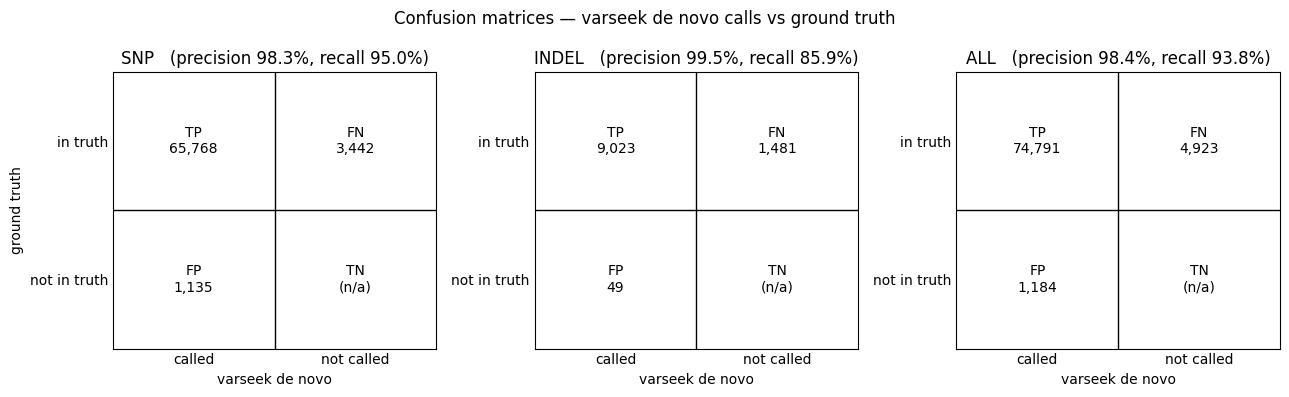

In [15]:
import numpy as np
import matplotlib.pyplot as plt


def happy_confusion_counts(summary_csv):
    """{type: (TP, FP, FN)} straight from a hap.py summary CSV (PASS rows), plus an
    ALL row summing SNP + INDEL.  TP/FN are truth-side, FP is query-side."""
    summ = pd.read_csv(summary_csv)
    summ = summ[summ["Filter"] == "PASS"].set_index("Type")
    cms = {t: (int(summ.loc[t, "TRUTH.TP"]), int(summ.loc[t, "QUERY.FP"]), int(summ.loc[t, "TRUTH.FN"]))
           for t in ("SNP", "INDEL")}
    cms["ALL"] = tuple(sum(v) for v in zip(cms["SNP"], cms["INDEL"]))
    return cms


def plot_confusion_matrices(summary_csv, tool="varseek", verbose=True):
    """Plain, color-free SNP / INDEL / ALL confusion matrices for one tool's hap.py run.
    The false-negative cell is printed but the TN cell is n/a (unbounded), so the
    matrices are read as: which of this tool's calls are real, and what did it miss."""
    cms = happy_confusion_counts(summary_csv)

    if verbose:
        print(f"{tool} — confusion counts (FN shown for reference, excluded from the matrices):")
        for name, (tp, fp, fn) in cms.items():
            print(f"  {name:5s}  TP={tp:>6,}   FP={fp:>5,}   FN={fn:>6,}   "
                  f"precision={tp/(tp+fp):.1%}, recall={tp/(tp+fn):.1%}")

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, (name, (tp, fp, fn)) in zip(axes, cms.items()):
        # rows = GIAB truth (in / not in), cols = the tool's call (called / not called).
        # FN (in-truth & not-called) is shown; TN (not-truth & not-called) is excluded.
        cells = [[f"TP\n{tp:,}", f"FN\n{fn:,}"],
                 [f"FP\n{fp:,}", "TN\n(n/a)"]]
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cells[i][j], ha="center", va="center", fontsize=10, color="black")
        ax.set_xlim(-0.5, 1.5); ax.set_ylim(1.5, -0.5)   # row 0 at top
        ax.axhline(0.5, color="black", lw=1); ax.axvline(0.5, color="black", lw=1)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["called", "not called"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["in truth", "not in truth"])
        ax.tick_params(length=0)
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_color("black")
        ax.set_title(f"{name}   (precision {tp/(tp+fp):.1%}, recall {tp/(tp+fn):.1%})")
        ax.set_xlabel(tool)
    axes[0].set_ylabel("ground truth")
    fig.suptitle(f"Confusion matrices — {tool} calls vs ground truth")
    plt.tight_layout(); plt.show()
    return cms


varseek_cms = plot_confusion_matrices(
    os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv"), tool="varseek de novo")

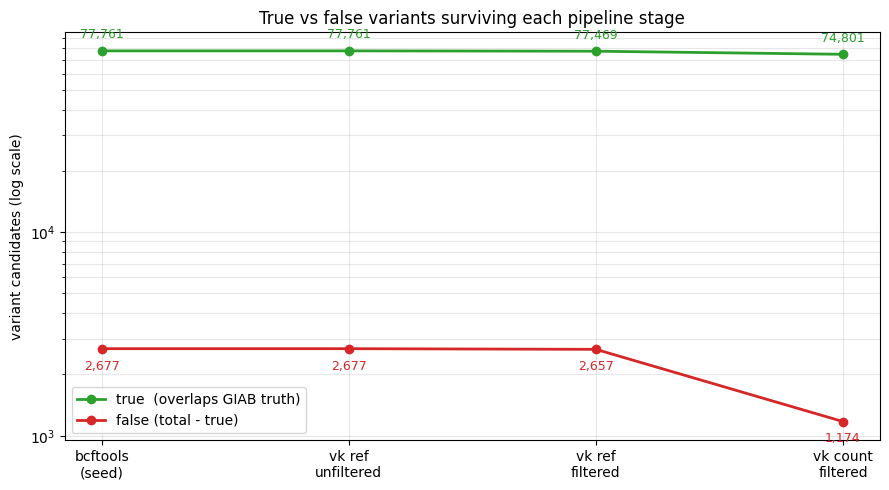

GIAB confident truth (chr20): 79,712 variants (69,210 SNP + 10,502 INDEL)

stage                     total     true   false  precision   recall
  bcftools (seed)        80,438   77,761   2,677     96.7%    97.6%
  vk ref unfiltered      80,438   77,761   2,677     96.7%    97.6%
  vk ref filtered        80,126   77,469   2,657     96.7%    97.2%
  vk count filtered      75,975   74,801   1,174     98.5%    93.8%


In [16]:
# =========================================================================
# True vs false variants surviving each pipeline stage:
#   bcftools seed  ->  vk ref unfiltered  ->  vk ref filtered  ->  vk count filtered
# Self-contained: a variant is "true" if it overlaps a GIAB confident truth
# variant (SNP matched by exact POS+REF+ALT; indel by a +/-3 bp position window,
# since HGVS and VCF anchor indels differently). false = total - true.
# =========================================================================
from bisect import bisect_left, bisect_right

# --- GIAB truth sets, restricted to the confident BED + PASS (chr20) ---
_bed = sorted(tuple(int(x) for x in l.split()[1:3]) for l in open(confident_bed))
_bed_starts = [b[0] for b in _bed]
def _in_bed(pos):                      # pos is 1-based; BED is 0-based half-open
    j = bisect_right(_bed_starts, pos - 1) - 1
    return j >= 0 and _bed[j][0] <= pos - 1 < _bed[j][1]

truth_snp, _truth_indel = set(), []
with gzip.open(truth_vcf, "rt") as fh:
    for ln in fh:
        if ln.startswith("#"):
            continue
        c, p, _id, ref, alt, _q, filt = ln.split("\t")[:7]
        if filt not in ("PASS", "."):
            continue
        p = int(p)
        if not _in_bed(p):
            continue
        alt = alt.split(",")[0]
        (truth_snp.add((p, ref, alt)) if len(ref) == 1 == len(alt) else _truth_indel.append(p))
truth_indel = np.array(sorted(_truth_indel))

# --- HGVS / VCF variant -> (kind, pos, ref, alt) ---
_snv = re.compile(r"g\.(\d+)([ACGT]+)>([ACGT]+)$")
_indel = re.compile(r"g\.(\d+)(?:_(\d+))?(?:ins|del|dup)")
def _classify(v):
    v = v.rsplit(":", 1)[-1]
    m = _snv.search(v)
    if m and len(m.group(2)) == 1 == len(m.group(3)):
        return ("snp", int(m.group(1)), m.group(2), m.group(3))
    m = _indel.search(v) or _snv.search(v)      # multi-base sub falls through to indel
    return ("indel", int(m.group(1)), None, None) if m else None

def _score(variants):
    tot = true = 0
    for v in variants:
        r = _classify(v)
        if r is None:
            continue
        tot += 1
        if r[0] == "snp":
            true += (r[1], r[2], r[3]) in truth_snp
        else:
            j = bisect_left(truth_indel, r[1] - 3)
            true += j < len(truth_indel) and truth_indel[j] <= r[1] + 3
    return tot, true

# --- collect each stage's variant list (variant-level; explode merged VCRS headers) ---
def _fa_vars(fa):
    return [v for l in open(fa) if l.startswith(">") for v in l[1:].strip().split(";")]

_seed = pd.read_csv(variants, sep="\t")
stage_vars = {
    "bcftools\n(seed)":        (_seed["seq_id"].astype(str) + ":" + _seed["variant"]).tolist(),
    "vk ref\nunfiltered":      _fa_vars(vcrs_unfiltered_fasta_out),
    "vk ref\nfiltered":        _fa_vars(os.path.join(vk_ref_out_dir, "vcrs.fa")),
    "vk count\nfiltered":      [f":g.{p}{ref}>{alt}" if len(ref) == 1 == len(alt) else f":g.{p}_{p}ins"
                                for ln in open(vk_count_variants_vcf) if not ln.startswith("#")
                                for _c, p, _i, ref, alt in [ln.split("\t")[:5]]],
}

steps       = list(stage_vars)
scored      = [_score(v) for v in stage_vars.values()]
total_steps = np.array([t for t, _ in scored])
true_steps  = np.array([tr for _, tr in scored])
false_steps = total_steps - true_steps
truth_total = len(truth_snp) + len(truth_indel)

# --- line graph: true vs false surviving each stage (log scale) ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(steps, true_steps,  "o-", color="tab:green", lw=2, label="true  (overlaps GIAB truth)")
ax.plot(steps, false_steps, "o-", color="tab:red",   lw=2, label="false (total - true)")
for x, (t, f) in enumerate(zip(true_steps, false_steps)):
    ax.annotate(f"{t:,}", (x, t), textcoords="offset points", xytext=(0, 9),  ha="center", color="tab:green", fontsize=9)
    ax.annotate(f"{f:,}", (x, f), textcoords="offset points", xytext=(0, -15), ha="center", color="tab:red",   fontsize=9)
ax.set_yscale("log")
ax.set_ylabel("variant candidates (log scale)")
ax.set_title("True vs false variants surviving each pipeline stage")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print(f"GIAB confident truth (chr20): {truth_total:,} variants "
      f"({len(truth_snp):,} SNP + {len(truth_indel):,} INDEL)\n")
print(f"{'stage':22s}{'total':>9s}{'true':>9s}{'false':>8s}{'precision':>11s}{'recall':>9s}")
for s, tot, tr, fa in zip(steps, total_steps, true_steps, false_steps):
    print(f"  {s.replace(chr(10),' '):20s}{tot:9,}{tr:9,}{fa:8,}"
          f"{tr/tot:10.1%}{tr/truth_total:9.1%}")

**Takeaway.** Switching the d-list from T2T to the calling assembly (GRCh38) is
**Pareto-better than the cDNA-only workaround on SNPs** — more true positives *and* fewer
false positives — and it is the biologically correct choice for DNA (reads come from the whole
genome, so the d-list must too). SNP recall roughly doubles (≈44% → ≈87%) at essentially
unchanged precision (≈99%); INDEL recall ≈29% → ≈58%.

The residual variants still dropped by the GRCh38 filter sit in genuine chr20 repeats — their
variant k-mer really does occur at a second locus that produces reads, so uniquely
pseudoaligning them is impossible. That is the irreducible ceiling for a k-mer method; the
T2T-vs-GRCh38 mismatch was the fixable part.

## Benchmark against the general-purpose callers (DeepVariant, GATK HaplotypeCaller, GATK Mutect2)

Having compared varseek's de novo calls directly to the GIAB ground truth above, we now run the
same three general-purpose callers used in [`vk_denovo.ipynb`](vk_denovo.ipynb) on these NA12878
chr20 reads and compare all call sets to one another (upset plot + lone-vs-corroborated analysis).

- **DeepVariant** consumes the paired **bowtie2** alignment produced by `vk denovo` (reheadered
  to carry the full reference contig dictionary — DeepVariant rejects a chr20-only BAM header as a
  genome-build mismatch). Because NA12878 is **DNA**, DeepVariant runs its standard **WGS** model
  here (not the RNA-seq model used in `vk_denovo.ipynb`); the RNA-seq model applied to genomic DNA
  systematically over-calls and produces a large block of spurious lone calls. We also keep only
  DeepVariant's **PASS** variant calls, dropping its `RefCall` (reference-genotype) records, so
  every caller is compared on the same "actual variant call" footing.
- **GATK HaplotypeCaller / Mutect2** run in the shared benchmarking scripts' **DNA mode**
  (`--dna`), which consumes the same **bowtie2** alignment and skips the RNA-seq-specific
  steps (STAR, `SplitNCigarReads`, `--dont-use-soft-clipped-bases`, and the splice-junction
  clustered-SNP `VariantFiltration`). So varseek, DeepVariant, and both GATK callers now
  share one DNA aligner (bowtie2).

VarTrix is single-cell-specific and is omitted here (this is a bulk paired-end DNA sample).

In [17]:
# --- Paths for the general-purpose callers (mirrors vk_denovo.ipynb) ---
scripts_dir = "/home/jrich/Desktop/RLSRP_2025/scripts"
gtf = os.path.join(reference_dir, "Homo_sapiens.GRCh38.114.gtf")
star_genome_index_dir = os.path.join(reference_dir, "star_index")
genomes1000_vcf = os.path.join(reference_dir, "1000GENOMES-phase_3.vcf")
picard_jar = "/home/jrich/opt/picard.jar"
java = "/home/jrich/opt/jdk-17.0.12+7/bin/java"
model_dir = os.path.join("data", "deepvariant_model")

gatk_out = os.path.join(root, "gatk_out")
tmp_dir = os.path.join(root, "tmp")
os.makedirs(tmp_dir, exist_ok=True)

# The paired bowtie2 alignment from vk denovo, plus a copy reheadered with the full
# reference contig dictionary for DeepVariant (see the next cell).
bowtie2_bam = os.path.join(denovo_bam_dir, "NA12878_chr20_R1_aligned_to_Homo_sapiens_GRCh38_dna_primary_assembly.bam")
bowtie2_bam_fullhdr = os.path.join(denovo_bam_dir, "bowtie2_chr20_fullhdr.bam")

deepvariant_vcf = os.path.join(gatk_out, "vcf_output", "deepvariant_variants.vcf.gz")
haplotypecaller_vcf = os.path.join(gatk_out, "vcfs", "haplotypecaller", "haplotypecaller_output_filtered_applied.vcf.gz")
mutect2_vcf = os.path.join(gatk_out, "vcfs", "mutect2", "mutect2_output_filtered_applied.vcf.gz")

In [18]:
# DeepVariant validates that BAM and reference share a genome build by checking contig
# overlap; the vk denovo bowtie2 BAM lists only chr20 (~2% of the reference) and is
# rejected. Reheader it to carry the full reference contig dictionary (chr20 kept at
# index 0 so existing read references stay valid); the reads themselves are unchanged.
if not os.path.exists(bowtie2_bam_fullhdr):
    ref_dict = sequences.replace(".fa", ".dict")
    if not os.path.exists(ref_dict):
        subprocess.run([java, "-jar", picard_jar, "CreateSequenceDictionary", "-R", sequences, "-O", ref_dict], check=True)
    hdr = subprocess.run(["samtools", "view", "-H", bowtie2_bam], capture_output=True, text=True).stdout.splitlines()
    hd_lines = [l for l in hdr if l.startswith("@HD")]
    pg_lines = [l for l in hdr if l.startswith("@PG")]
    def _sn_ln(l):
        d = dict(f.split(":", 1) for f in l.rstrip("\n").split("\t")[1:] if ":" in f)
        return f"@SQ\tSN:{d['SN']}\tLN:{d['LN']}"
    dict_sq = {_sn_ln(l).split("\t")[1][3:]: _sn_ln(l) for l in open(ref_dict) if l.startswith("@SQ")}
    ordered_sq = [dict_sq["20"]] + [v for key, v in dict_sq.items() if key != "20"]
    hdr_path = os.path.join(denovo_bam_dir, "full_header.sam")
    with open(hdr_path, "w") as fh:
        fh.write("\n".join(hd_lines + ordered_sq + pg_lines) + "\n")
    subprocess.run(f"samtools reheader {hdr_path} {bowtie2_bam} > {bowtie2_bam_fullhdr}", shell=True, check=True)
    subprocess.run(["samtools", "index", bowtie2_bam_fullhdr], check=True)
    print(f"Wrote {bowtie2_bam_fullhdr}")
else:
    print(f"{bowtie2_bam_fullhdr} already exists.")

data/na12878_chr20/varseek_denovo_out/bams/bowtie2_chr20_fullhdr.bam already exists.


In [19]:
# DeepVariant on the paired bowtie2 alignment (reheadered). Because NA12878 is DNA (WGS),
# we run DeepVariant's standard WGS model (--dna_model_type WGS) on the bowtie2 (DNA)
# alignment -- NOT the customized RNA-seq model used by vk_denovo.ipynb. The RNA-seq model
# assumes spliced reads and, applied to genomic DNA, systematically over-calls (it emitted
# ~166k chr20 calls vs ~84k GIAB truth). The WGS model is DeepVariant's intended mode here.
# --aligned_bam bypasses the script's STAR step, so read_length only tags the (unused)
# STAR params.
if not os.path.exists(deepvariant_vcf):
    _t0 = time.perf_counter()
    !python {scripts_dir}/run_deepvariant_for_benchmarking.py \
        --synthetic_read_fastq {r1} \
        --aligned_bam {bowtie2_bam_fullhdr} \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --star_genome_dir {star_genome_index_dir} \
        --read_length {read_length} \
        --threads {threads} \
        --model_dir {model_dir} \
        --dna_model_type WGS \
        --docker podman \
        --out {gatk_out} \
        --skip_accuracy_analysis
    save_runtime("deepvariant", time.perf_counter() - _t0)

In [20]:
# GATK HaplotypeCaller in DNA mode (--dna --aligned_bam): reuse the vk denovo **bowtie2**
# (DNA) alignment and skip the RNA-seq-specific steps -- STAR, SplitNCigarReads,
# --dont-use-soft-clipped-bases, and the splice-junction clustered-SNP VariantFiltration.
# This matches the aligner used by varseek and DeepVariant, so every caller is compared on
# the same DNA alignment. (r1/r2 are still passed but only tag unused STAR/FastqToSam params.)
if not os.path.exists(haplotypecaller_vcf):
    _t0 = time.perf_counter()
    !python {scripts_dir}/run_gatk_haplotypecaller_for_benchmarking.py \
        --synthetic_read_fastq {r1} \
        --synthetic_read_fastq2 {r2} \
        --aligned_bam {bowtie2_bam} \
        --dna \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --genomes1000_vcf {genomes1000_vcf} \
        --read_length {read_length} \
        --threads {threads} \
        --picard_jar {picard_jar} \
        --java {java} \
        --tmp_dir {tmp_dir} \
        --out {gatk_out} \
        --skip_accuracy_analysis
    save_runtime("haplotypecaller", time.perf_counter() - _t0)

In [21]:
# GATK Mutect2 in DNA mode (--dna --aligned_bam): reuses the bowtie2 alignment + BQSR bam
# built by the HaplotypeCaller cell, and drops --dont-use-soft-clipped-bases for DNA.
if not os.path.exists(mutect2_vcf):
    _t0 = time.perf_counter()
    !python {scripts_dir}/run_gatk_mutect2_for_benchmarking.py \
        --synthetic_read_fastq {r1} \
        --synthetic_read_fastq2 {r2} \
        --aligned_bam {bowtie2_bam} \
        --dna \
        --reference_genome_fasta {sequences} \
        --reference_genome_gtf {gtf} \
        --genomes1000_vcf {genomes1000_vcf} \
        --read_length {read_length} \
        --threads {threads} \
        --picard_jar {picard_jar} \
        --java {java} \
        --tmp_dir {tmp_dir} \
        --out {gatk_out} \
        --skip_accuracy_analysis
    save_runtime("mutect2", time.perf_counter() - _t0)

In [22]:
# ---------------------------------------------------------------------------
# VCF normalization helpers (ported from vk_denovo.ipynb) so every caller's calls
# share a common coordinate representation before the upset / lone analyses.
# ---------------------------------------------------------------------------
import gzip

def is_vcf_normalized(vcf_path):
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("##bcftools_normCommand="):
                return True
            if not line.startswith("##"):
                break
    return False

def ensure_genotype_column(vcf_path, sample_name="SAMPLE", genotype="1/1"):
    """hap.py/normalization convenience: inject a placeholder FORMAT/GT column into a
    sites-only VCF (varseek). No-op for VCFs that already carry sample columns."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        lines = f.readlines()
    for line in lines:
        if line.startswith("#CHROM"):
            if len(line.rstrip("\n").split("\t")) > 8:
                return
            break
    gt_header = '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">\n'
    new_lines, inserted_header = [], False
    for line in lines:
        if line.startswith("##"):
            new_lines.append(line)
        elif line.startswith("#CHROM"):
            if not inserted_header:
                new_lines.append(gt_header); inserted_header = True
            new_lines.append("\t".join(line.rstrip("\n").split("\t") + ["FORMAT", sample_name]) + "\n")
        elif line.strip():
            new_lines.append("\t".join(line.rstrip("\n").split("\t") + ["GT", genotype]) + "\n")
    with open(vcf_path, "wt") as f:
        f.writelines(new_lines)

def insert_suffix_before_first_dot(path, suffix):
    dirname, basename = os.path.split(path)
    if "." in basename:
        parts = basename.split(".", 1)
        new_basename = parts[0] + suffix + "." + parts[1]
    else:
        new_basename = basename + suffix
    return os.path.join(dirname, new_basename)

def add_normalized_before_first_dot(path):
    return insert_suffix_before_first_dot(path, "_normalized")

def _vcf_has_samples(vcf_path):
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#CHROM"):
                return len(line.rstrip("\n").split("\t")) > 8
            if not line.startswith("#"):
                break
    return False

def filter_to_variant_calls(vcf_path):
    """Keep PASS variant calls: records with a real ALT allele (ALT!=".") whose FILTER
    is PASS or unset (".").  This drops gVCF reference blocks (ALT=".") and, crucially,
    DeepVariant's RefCall records -- sites it explicitly genotypes as reference (GT 0/0).
    Every other caller here is already PASS-only, so this only affects DeepVariant and
    puts all tracks on the same footing (a fair \"variant call\" comparison).  Sites-only
    VCFs (varseek) are returned unchanged."""
    if not _vcf_has_samples(vcf_path):
        return vcf_path
    out_path = insert_suffix_before_first_dot(vcf_path, "_nonref")
    if os.path.isfile(out_path) and os.path.getsize(out_path) > 0:
        print(f"Filtered file {out_path} already exists. Skipping filtering.")
    else:
        output_type = "-Oz" if out_path.endswith(".vcf.gz") else "-Ov"
        subprocess.run(["bcftools", "view", "-i", 'ALT!="." && (FILTER="PASS" || FILTER=".")', output_type, "-o", out_path, vcf_path], check=True)
    return out_path

def make_normalized_vcf(test_vcf, reference_fasta):
    test_vcf_unnormalized = test_vcf
    test_vcf = add_normalized_before_first_dot(test_vcf_unnormalized)
    if os.path.isfile(test_vcf) and os.path.getsize(test_vcf) > 0:
        print(f"Normalized file {test_vcf} already exists. Skipping normalization.")
    else:
        reference_fasta_index = f"{reference_fasta}.fai"
        if not os.path.isfile(reference_fasta_index):
            subprocess.run(["samtools", "faidx", reference_fasta], check=True)
        output_type = "-Oz" if test_vcf.endswith(".vcf.gz") else "-Ov"
        # reheader (add contig lines from the reference) -> left-normalize/split -> sort.
        reheader_proc = subprocess.Popen(
            ["bcftools", "reheader", "--fai", reference_fasta_index, test_vcf_unnormalized], stdout=subprocess.PIPE)
        norm_proc = subprocess.Popen(
            ["bcftools", "norm", "-c", "w", "-f", reference_fasta, "-m", "-both", "-Ou"],
            stdin=reheader_proc.stdout, stdout=subprocess.PIPE)
        reheader_proc.stdout.close()
        subprocess.run(["bcftools", "sort", output_type, "-o", test_vcf], stdin=norm_proc.stdout, check=True)
        norm_proc.stdout.close()
        if reheader_proc.wait() != 0:
            raise subprocess.CalledProcessError(reheader_proc.returncode, "bcftools reheader")
        if norm_proc.wait() != 0:
            raise subprocess.CalledProcessError(norm_proc.returncode, "bcftools norm")
    ensure_genotype_column(test_vcf)  # sites-only VCFs (varseek) get a placeholder GT
    if test_vcf.endswith(".gz") and not os.path.isfile(f"{test_vcf}.tbi"):
        subprocess.run(["bcftools", "index", "-f", "-t", test_vcf], check=True)
    return test_vcf

In [23]:
# Left-align + multiallelic-split every call set so all callers share one coordinate
# representation (the same normalization compare_with_happy applies in vk_denovo.ipynb),
# then restrict to chr20. The reads were extracted from chr20, but STAR aligns the two
# GATK callers against the whole genome and a few reads mis-map off-chr20, so we scope
# every caller to chr20 for a fair comparison (varseek/bcftools/DeepVariant are already
# chr20-only, so this is a no-op for them).
# The caller-concordance comparison below uses the d-list-FIX varseek calls
# (GRCh38 genome d-list; see "The real cause — and the fix" above), produced by
# build_and_evaluate("GRCh38_genome", ...). This is the varseek pipeline rerun with
# the corrected d-listing strategy.
varseek_calls_vcf = os.path.join(root, "varseek_count_out", "varseek_variants.vcf")
caller_raw_vcfs = {
    "varseek":         varseek_calls_vcf,
    "bcftools":        variants_vcf,
    "deepvariant":     deepvariant_vcf,
    "haplotypecaller": haplotypecaller_vcf,
    "mutect2":         mutect2_vcf,
}
for name, vcf in caller_raw_vcfs.items():
    if not vcf or not os.path.exists(vcf):
        print(f"WARNING: {name} VCF missing ({vcf}); skipping normalization.")
        continue
    norm = make_normalized_vcf(filter_to_variant_calls(vcf), sequences)
    otype = "z" if norm.endswith(".gz") else "v"
    subprocess.run(f"bcftools view -t 20 -O{otype} -o {norm}.tmp {norm} && mv {norm}.tmp {norm}",
                   shell=True, check=True)
    if norm.endswith(".gz"):
        subprocess.run(["bcftools", "index", "-f", "-t", norm], check=True)
    n_chr20 = subprocess.run(["bcftools", "view", "-H", norm], capture_output=True, text=True).stdout.count("\n")
    print(f"{name}: {n_chr20:,} chr20 records -> {os.path.basename(norm)}")
print("Normalized (chr20-restricted) VCFs ready.")

Writing to /home/jrich/tmp/bcftools.RySMjb
Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	75975/0/0/0/0/0/0
Merging 1 temporary files
Done
Cleaning


varseek: 75,975 chr20 records -> varseek_variants_normalized.vcf
Filtered file data/na12878_chr20/varseek_denovo_out/variants_nonref.vcf.gz already exists. Skipping filtering.
Normalized file data/na12878_chr20/varseek_denovo_out/variants_nonref_normalized.vcf.gz already exists. Skipping normalization.


[W::bcf_hdr_check_sanity] MQ should be declared as Type=Float


bcftools: 80,438 chr20 records -> variants_nonref_normalized.vcf.gz
Filtered file data/na12878_chr20/gatk_out/vcf_output/deepvariant_variants_nonref.vcf.gz already exists. Skipping filtering.
Normalized file data/na12878_chr20/gatk_out/vcf_output/deepvariant_variants_nonref_normalized.vcf.gz already exists. Skipping normalization.
deepvariant: 95,109 chr20 records -> deepvariant_variants_nonref_normalized.vcf.gz
Filtered file data/na12878_chr20/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
Normalized file data/na12878_chr20/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz already exists. Skipping normalization.
haplotypecaller: 97,821 chr20 records -> haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz
Filtered file data/na12878_chr20/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
Normalized file da

### Upset plot: variant call overlap across callers

Compare the variant call sets of varseek, DeepVariant, GATK HaplotypeCaller, GATK Mutect2, and
bcftools (varseek's own de novo seed) as an upset plot, using the normalized VCFs so all callers
share a common coordinate representation.

varseek: 75,975 variants (data/na12878_chr20/varseek_count_out/varseek_variants_normalized.vcf)
deepvariant: 95,109 variants (data/na12878_chr20/gatk_out/vcf_output/deepvariant_variants_nonref_normalized.vcf.gz)
haplotypecaller: 97,821 variants (data/na12878_chr20/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref_normalized.vcf.gz)
mutect2: 71,316 variants (data/na12878_chr20/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref_normalized.vcf.gz)
bcftools: 80,438 variants (data/na12878_chr20/varseek_denovo_out/variants_nonref_normalized.vcf.gz)
Saved upset plot to data/na12878_chr20/happy_output/upset_callers.png


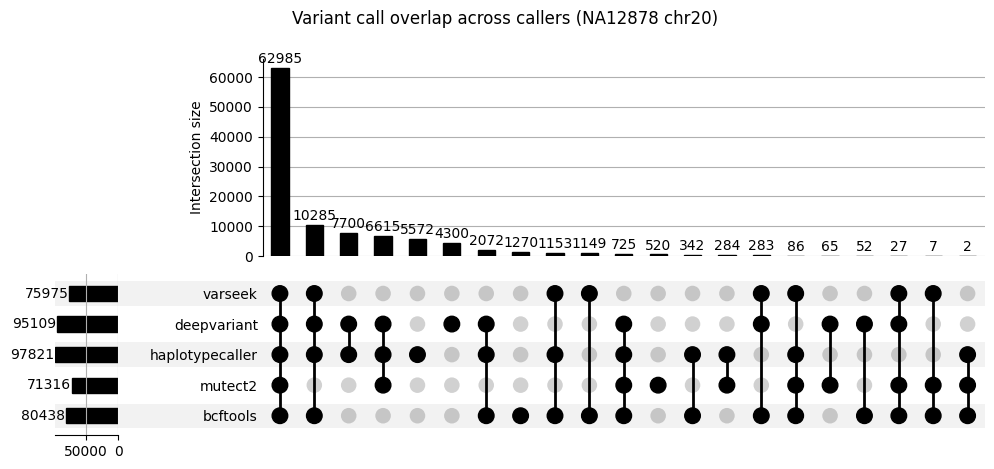

In [24]:
try:
    import upsetplot
except ImportError:
    print("upsetplot not found, installing...")
    !pip install -U -q upsetplot
    import upsetplot

import matplotlib.pyplot as plt
from upsetplot import from_contents, UpSet


def read_variant_set(vcf_path):
    """Read a (optionally gzipped) VCF into a set of (CHROM, POS, REF, ALT) keys.
    Multiallelic ALTs are split so each allele is counted separately."""
    if not vcf_path or not os.path.exists(vcf_path):
        return None
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    keys = set()
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            for a in alt.split(","):
                keys.add((chrom, pos, ref, a))
    return keys


# Normalized (left-aligned, multiallelic-split) VCFs -> common coordinate representation.
caller_vcfs = {
    "varseek": add_normalized_before_first_dot(varseek_calls_vcf),
    "deepvariant": add_normalized_before_first_dot(insert_suffix_before_first_dot(deepvariant_vcf, "_nonref")),
    "haplotypecaller": add_normalized_before_first_dot(insert_suffix_before_first_dot(haplotypecaller_vcf, "_nonref")),
    "mutect2": add_normalized_before_first_dot(insert_suffix_before_first_dot(mutect2_vcf, "_nonref")),
    "bcftools": add_normalized_before_first_dot(insert_suffix_before_first_dot(variants_vcf, "_nonref")),
}

caller_sets = {}
for name, path in caller_vcfs.items():
    s = read_variant_set(path)
    if s is None:
        print(f"WARNING: normalized VCF for {name} not found at {path}; excluding from upset plot.")
        continue
    caller_sets[name] = s
    print(f"{name}: {len(s):,} variants ({path})")

if len(caller_sets) >= 2:
    upset_data = from_contents(caller_sets)
    fig = plt.figure(figsize=(11, 6))
    UpSet(upset_data, subset_size="count", show_counts=True, sort_by="cardinality", sort_categories_by="-input").plot(fig=fig)
    fig.suptitle("Variant call overlap across callers (NA12878 chr20)")

    upset_png = os.path.join(happy_out, "upset_callers.png")
    os.makedirs(happy_out, exist_ok=True)
    fig.savefig(upset_png, dpi=150, bbox_inches="tight")
    print(f"Saved upset plot to {upset_png}")
    plt.show()
else:
    print("Need at least two caller sets to build an upset plot.")

### Are *any* tool's lone calls likely real?

Each tool in the upset plot reports its own block of **lone** calls — variants it alone recovers,
corroborated by no other caller. Are those genuine variants the others miss, or mostly
tool-specific false positives? For every caller we split its calls into **lone** vs
**corroborated** (against the union of the other tools) and profile each group by known-germline
overlap (1000 Genomes), Ti/Tv ratio, read depth, and single-alt-read support — the same
assessment applied in `vk_denovo.ipynb`. Because NA12878 is a healthy germline sample, genuine
calls should be strongly enriched for known 1000G sites and carry a transition-heavy Ti/Tv.

In [25]:
# ---------------------------------------------------------------------------
# Reusable building blocks for the per-tool lone-call assessment. These reuse the
# read_variant_set / *_before_first_dot helpers defined earlier in the notebook.
# ---------------------------------------------------------------------------
import numpy as np

TRANSITIONS = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}

def _info_dict(info):
    return dict(f.split("=", 1) for f in info.split(";") if "=" in f)

def _num(x, idx=0):
    """idx-th comma-separated value of a VCF field as float (NaN on failure)."""
    try:
        return float(str(x).split(",")[idx])
    except (ValueError, IndexError, AttributeError, TypeError):
        return np.nan

def read_variant_records(vcf_path):
    """Read a normalized VCF into {(CHROM,POS,REF,ALT): {DP, alt_AD, AF}}.
    DP and alt-allele read count come from the FORMAT sample column if present, else
    INFO; AF from FORMAT AF/VAF or alt_AD/DP. Sites-only VCFs (varseek) yield NaN
    evidence -- which is why the varseek group also reads the bcftools VCF."""
    if not vcf_path or not os.path.exists(vcf_path):
        return {}
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    out = {}
    with open_func(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            info = cols[7] if len(cols) > 7 else "."
            idict = _info_dict(info) if info not in (".", "") else {}
            fmt_sample = {}
            if len(cols) >= 10:
                fmt_sample = dict(zip(cols[8].split(":"), cols[9].split(":")))
            DP = _num(fmt_sample.get("DP", idict.get("DP")))
            alt_AD = _num(fmt_sample.get("AD", idict.get("AD")), 1)  # ref,alt -> alt
            AF = fmt_sample.get("AF") or fmt_sample.get("VAF")
            AF = _num(AF) if AF is not None else (alt_AD / DP if DP and DP > 0 else np.nan)
            for a in alt.split(","):
                out[(chrom, pos, ref, a)] = {"DP": DP, "alt_AD": alt_AD, "AF": AF}
    return out

def classify(ref, alt):
    is_snv = len(ref) == 1 and len(alt) == 1 and ref in "ACGT" and alt in "ACGT"
    return {"is_snv": is_snv, "is_indel": len(ref) != len(alt),
            "ti": is_snv and (ref, alt) in TRANSITIONS,
            "tv": is_snv and (ref, alt) not in TRANSITIONS}

def build_germline_lookups(all_keys, genomes1000_vcf, cache_tsv):
    """Stream the (~12 GB) 1000 Genomes VCF once over the union of query sites and
    return (pos_hits, allele_hits): known polymorphic (CHROM,POS) and exact
    (CHROM,POS,REF,ALT). Cached to TSV so re-runs skip the streaming pass."""
    if not os.path.exists(genomes1000_vcf):
        print(f"1000 Genomes VCF not found at {genomes1000_vcf}; skipping germline overlap.")
        return None, None
    if not (os.path.isfile(cache_tsv) and os.path.getsize(cache_tsv) > 0):
        targets_tsv = cache_tsv + ".targets"
        sites = sorted({(key[0], int(key[1])) for key in all_keys})
        with open(targets_tsv, "w") as fh:
            fh.writelines(f"{c}\t{p}\n" for c, p in sites)
        print(f"Streaming 1000 Genomes for {len(sites):,} unique sites "
              f"(one pass over {genomes1000_vcf}, this can take a few minutes)...")
        with open(cache_tsv, "w") as out:
            subprocess.run(["bcftools", "view", "-H", "-T", targets_tsv, genomes1000_vcf],
                           stdout=out, check=True)
    else:
        print(f"Using cached 1000 Genomes hits: {cache_tsv}")
    pos_hits, allele_hits = set(), set()
    with open(cache_tsv) as fh:
        for line in fh:
            cols = line.rstrip("\n").split("\t")
            if len(cols) < 5:
                continue
            chrom, pos, _id, ref, alt = cols[:5]
            pos_hits.add((chrom, pos))
            for a in alt.split(","):
                allele_hits.add((chrom, pos, ref, a))
    return pos_hits, allele_hits

def assess_tool(tool, group_keys, other_union, evidence, pos_hits, allele_hits):
    """Partition a tool's calls into lone vs corroborated and build a per-call
    table tagged with SNV/indel class, read evidence, and germline overlap."""
    have_germ = pos_hits is not None
    rows = []
    for key in group_keys:
        chrom, pos, ref, alt = key
        ev = evidence.get(key, {})
        row = {"tool": tool, "key": key,
               "group": "corroborated" if key in other_union else "lone",
               **classify(ref, alt),
               "DP": ev.get("DP", np.nan), "alt_AD": ev.get("alt_AD", np.nan),
               "AF": ev.get("AF", np.nan)}
        row["single_read"] = row["alt_AD"] <= 1   # rests on a single alt read (NaN -> False)
        if have_germ:
            row["in_1000G_site"] = (chrom, pos) in pos_hits
            row["in_1000G_allele"] = key in allele_hits
        rows.append(row)
    return pd.DataFrame(rows)

def group_summary(df, have_germ, have_reads):
    ti, tv = int(df["ti"].sum()), int(df["tv"].sum())
    out = {"n": len(df), "% indel": 100 * df["is_indel"].mean(),
           "Ti/Tv (SNVs)": (ti / tv) if tv else np.nan}
    if have_reads:
        ev = df[df["alt_AD"].notna()]
        out["% w/ read evidence"] = 100 * len(ev) / len(df) if len(df) else np.nan
        out["% single alt read"] = 100 * ev["single_read"].mean() if len(ev) else np.nan
        out["median DP"] = df["DP"].median()
        out["median alt_AD"] = df["alt_AD"].median()
        out["median AF"] = df["AF"].median()
    if have_germ:
        out["% on 1000G site"] = 100 * df["in_1000G_site"].mean()
        out["% exact allele in 1000G"] = 100 * df["in_1000G_allele"].mean()
    return out

In [26]:
# ---------------------------------------------------------------------------
# Build each tool group's normalized variant set + read evidence, then assess
# lone vs corroborated for every tool against the union of the OTHER tools.
# ---------------------------------------------------------------------------
tool_norm_vcfs = {
    # varseek is sites-only; bcftools (its de novo seed) is pooled in and supplies
    # the read evidence. Listing bcftools second lets its records fill the evidence
    # dict for the shared keys.
    "varseek+bcftools": [
        add_normalized_before_first_dot(vk_count_variants_vcf),
        add_normalized_before_first_dot(insert_suffix_before_first_dot(variants_vcf, "_nonref")),
    ],
    "deepvariant":     [add_normalized_before_first_dot(insert_suffix_before_first_dot(deepvariant_vcf, "_nonref"))],
    "haplotypecaller": [add_normalized_before_first_dot(insert_suffix_before_first_dot(haplotypecaller_vcf, "_nonref"))],
    "mutect2":         [add_normalized_before_first_dot(insert_suffix_before_first_dot(mutect2_vcf, "_nonref"))],
}

tool_sets, tool_evidence = {}, {}
for tool, paths in tool_norm_vcfs.items():
    keys, ev = set(), {}
    for p in paths:
        s = read_variant_set(p)
        if s is None:
            print(f"WARNING: missing normalized VCF for {tool}: {p}")
            continue
        keys |= s
        ev.update(read_variant_records(p))   # later path (bcftools) fills varseek's gaps
    tool_sets[tool] = keys
    tool_evidence[tool] = ev
    n_ev = sum(1 for v in ev.values() if not np.isnan(v["alt_AD"]))
    print(f"{tool}: {len(keys):,} variant alleles ({n_ev:,} with read evidence)")

all_keys = set().union(*tool_sets.values())
print(f"\nUnion across all tools: {len(all_keys):,} alleles")

pos_hits, allele_hits = build_germline_lookups(
    all_keys, genomes1000_vcf, os.path.join(happy_out, "all_tools_sites_in_1000G.tsv"))

per_tool, summary_rows = {}, []
for tool, keys in tool_sets.items():
    other_union = set().union(*[s for t, s in tool_sets.items() if t != tool])
    df = assess_tool(tool, keys, other_union, tool_evidence[tool], pos_hits, allele_hits)
    per_tool[tool] = df
    have_reads = df["alt_AD"].notna().any()
    have_germ = pos_hits is not None
    n_lone = int((df["group"] == "lone").sum())
    print(f"{tool}: {n_lone:,}/{len(df):,} lone ({100*n_lone/len(df):.1f}%)")
    for grp in ["lone", "corroborated"]:
        summary_rows.append({"tool": tool, "group": grp,
                             **group_summary(df[df["group"] == grp], have_germ, have_reads)})

lone_summary = pd.DataFrame(summary_rows)
print("\nLone vs corroborated, per tool:")
display(lone_summary.round(2))
lone_summary.to_csv(os.path.join(happy_out, "lone_calls_summary.csv"), index=False)

varseek+bcftools: 80,438 variant alleles (80,438 with read evidence)
deepvariant: 95,109 variant alleles (95,109 with read evidence)
haplotypecaller: 97,821 variant alleles (97,821 with read evidence)
mutect2: 71,316 variant alleles (71,316 with read evidence)

Union across all tools: 105,494 alleles
Using cached 1000 Genomes hits: data/na12878_chr20/happy_output/all_tools_sites_in_1000G.tsv
varseek+bcftools: 2,419/80,438 lone (3.0%)
deepvariant: 4,300/95,109 lone (4.5%)
haplotypecaller: 5,572/97,821 lone (5.7%)
mutect2: 520/71,316 lone (0.7%)

Lone vs corroborated, per tool:


,tool,group,n,% indel,Ti/Tv (SNVs),% w/ read evidence,% single alt read,median DP,median alt_AD,median AF,% on 1000G site,% exact allele in 1000G
0,varseek+bcftools,lone,2419,3.60,0.83,100.0,0.00,25.0,9.0,0.39,19.97,17.90
1,varseek+bcftools,corroborated,78019,12.28,2.29,100.0,0.00,31.0,19.0,0.57,87.07,86.60
2,deepvariant,lone,4300,45.88,1.54,100.0,0.00,16.5,5.0,0.50,14.98,13.26
3,deepvariant,corroborated,90809,19.20,2.22,100.0,0.00,30.0,18.0,0.58,80.15,79.26
4,haplotypecaller,lone,5572,27.21,1.62,100.0,2.30,25.0,7.0,0.36,14.54,10.34
5,haplotypecaller,corroborated,92249,19.06,2.22,100.0,0.20,28.0,17.0,0.58,79.79,78.89
6,mutect2,lone,520,6.15,1.97,100.0,4.23,28.0,16.0,0.55,76.15,2.50
7,mutect2,corroborated,70796,14.61,2.26,100.0,0.02,29.0,18.0,0.58,85.31,84.68


Saved figure to data/na12878_chr20/happy_output/lone_calls_by_tool.png


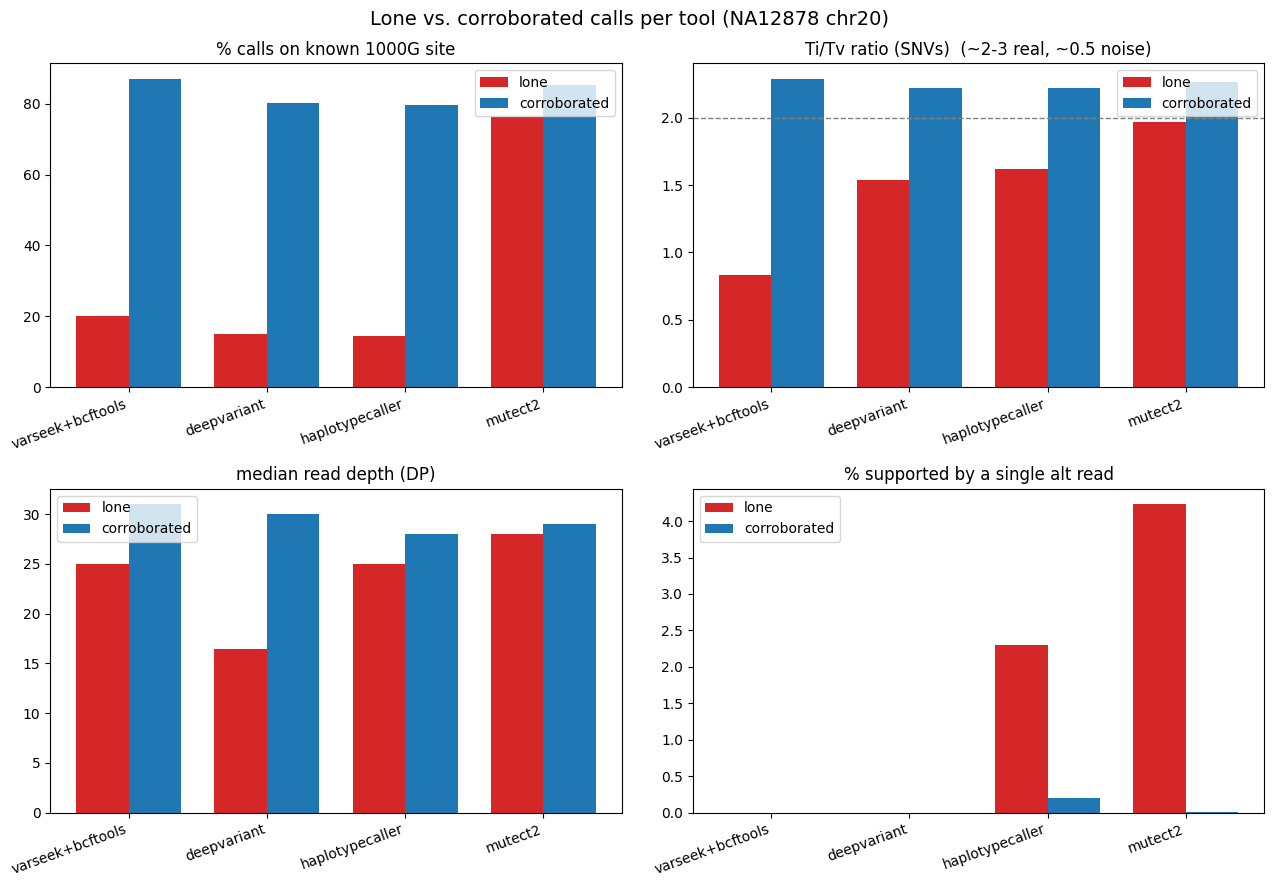


Lone calls stratified by read support:


,tool,support,n,% on 1000G site,Ti/Tv (SNVs)
0,varseek+bcftools,multi-read,2419,19.97,0.83
1,deepvariant,multi-read,4300,14.98,1.54
2,haplotypecaller,multi-read,5444,14.70,1.65
3,haplotypecaller,single-read,128,7.81,0.65
4,mutect2,multi-read,498,79.32,2.13
5,mutect2,single-read,22,4.55,1.50


In [27]:
# ---------------------------------------------------------------------------
# Visual summary: lone vs corroborated per tool, one metric per panel; plus the
# within-lone "is the real signal where there is >1 read?" stratification.
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt

TOOLS = list(per_tool.keys())
COL = {"lone": "#d62728", "corroborated": "#1f77b4"}
x = np.arange(len(TOOLS)); width = 0.38

def _metric(metric, grp):
    return [lone_summary[(lone_summary.tool == t) & (lone_summary.group == grp)][metric].iloc[0]
            for t in TOOLS]

panels = [
    ("% on 1000G site",    "% calls on known 1000G site", None),
    ("Ti/Tv (SNVs)",       "Ti/Tv ratio (SNVs)  (~2-3 real, ~0.5 noise)", 2.0),
    ("median DP",          "median read depth (DP)", None),
    ("% single alt read",  "% supported by a single alt read", None),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (metric, title, hline) in zip(axes.ravel(), panels):
    ax.bar(x - width/2, _metric(metric, "lone"), width, label="lone", color=COL["lone"])
    ax.bar(x + width/2, _metric(metric, "corroborated"), width, label="corroborated", color=COL["corroborated"])
    if hline is not None:
        ax.axhline(hline, ls="--", c="gray", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(TOOLS, rotation=20, ha="right")
    ax.set_title(title); ax.legend()
fig.suptitle("Lone vs. corroborated calls per tool (NA12878 chr20)", fontsize=14)
fig.tight_layout()
lone_fig_path = os.path.join(happy_out, "lone_calls_by_tool.png")
fig.savefig(lone_fig_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to {lone_fig_path}")
plt.show()

# Within each tool's lone set, split by read support: does germline overlap /
# Ti/Tv concentrate where there is more than one supporting read?
strat_rows = []
for tool, df in per_tool.items():
    ev = df[(df["group"] == "lone") & df["alt_AD"].notna()]
    if ev.empty:
        continue
    for label, sub in ev.groupby(np.where(ev["single_read"], "single-read", "multi-read")):
        ti, tv = int(sub["ti"].sum()), int(sub["tv"].sum())
        strat_rows.append({"tool": tool, "support": label, "n": len(sub),
                           "% on 1000G site": 100 * sub["in_1000G_site"].mean() if pos_hits is not None else np.nan,
                           "Ti/Tv (SNVs)": (ti / tv) if tv else np.nan})
print("\nLone calls stratified by read support:")
display(pd.DataFrame(strat_rows).round(2))

### Confusion matrices for every caller (hap.py vs GIAB truth)

The confusion matrices above judged varseek against the GIAB truth set. Because NA12878 has a
gold-standard truth, we can do exactly the same for **every** caller instead of only comparing
call sets to one another — each tool's normalized chr20 calls are run through the same `hap.py`
benchmark (same truth VCF, same high-confidence BED, same `scmp-somatic` allele-matching engine,
which ignores genotypes so the sites-only varseek track is not unfairly penalized). The result is
a like-for-like precision/recall table plus the same three-panel confusion matrix per tool.

In [28]:
# ---------------------------------------------------------------------------
# Run hap.py for each of the other callers against the same GIAB truth, reusing
# the chr20-restricted normalized VCFs built above.  Guarded by output existence,
# so re-running the cell is cheap.
# ---------------------------------------------------------------------------
def run_happy_for_tool(query_vcf, tool, happy_dir=None):
    """hap.py: GIAB truth vs one caller's normalized VCF. Returns the summary CSV path."""
    happy_dir = happy_dir or os.path.join(root, "happy_output_per_tool", tool)
    prefix = os.path.join(os.path.abspath(happy_dir), f"{tool}_vs_giab_truth")
    summary = f"{prefix}.summary.csv"
    if os.path.isfile(summary):
        print(f"[{tool}] hap.py summary exists - skipping")
        return summary
    os.makedirs(happy_dir, exist_ok=True)
    # hap.py needs a bgzipped + tabix-indexed query
    if not query_vcf.endswith(".gz"):
        gz = query_vcf + ".gz"
        if not os.path.isfile(gz):
            subprocess.run(f"bgzip -c {query_vcf} > {gz}", shell=True, check=True)
        query_vcf = gz
    if not os.path.isfile(query_vcf + ".tbi"):
        subprocess.run(["bcftools", "index", "-f", "-t", query_vcf], check=True)

    mount_dirs = sorted({os.path.abspath(root), os.path.abspath(reference_dir)})
    mounts = " ".join(f"-v {d}:{d}" for d in mount_dirs)
    cmd = (f"podman run --rm {mounts} "
           f"mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py "
           f"-r {os.path.abspath(sequences)} -f {os.path.abspath(confident_bed)} "
           f"--location 20 --threads {threads} --engine=scmp-somatic -o {prefix} "
           f"{os.path.abspath(truth_vcf)} {os.path.abspath(query_vcf)}")
    print(cmd)
    subprocess.run(cmd, shell=True, check=True)
    return summary


# Same normalized, chr20-restricted call sets used by the upset plot.  varseek reuses
# the hap.py run from the top of the notebook (identical truth/BED/engine).
happy_summaries = {"varseek": os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")}
for tool, raw_vcf in caller_raw_vcfs.items():
    if tool == "varseek":
        continue
    if not raw_vcf or not os.path.exists(raw_vcf):
        print(f"WARNING: {tool} VCF missing ({raw_vcf}); skipping hap.py.")
        continue
    happy_summaries[tool] = run_happy_for_tool(
        add_normalized_before_first_dot(filter_to_variant_calls(raw_vcf)), tool)

print("\nhap.py summaries:")
for tool, s in happy_summaries.items():
    print(f"  {tool:16s} {s}")

Filtered file data/na12878_chr20/varseek_denovo_out/variants_nonref.vcf.gz already exists. Skipping filtering.
[bcftools] hap.py summary exists - skipping
Filtered file data/na12878_chr20/gatk_out/vcf_output/deepvariant_variants_nonref.vcf.gz already exists. Skipping filtering.
[deepvariant] hap.py summary exists - skipping
Filtered file data/na12878_chr20/gatk_out/vcfs/haplotypecaller/haplotypecaller_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
[haplotypecaller] hap.py summary exists - skipping
Filtered file data/na12878_chr20/gatk_out/vcfs/mutect2/mutect2_output_filtered_applied_nonref.vcf.gz already exists. Skipping filtering.
[mutect2] hap.py summary exists - skipping

hap.py summaries:
  varseek          data/na12878_chr20/happy_output/varseek_vs_giab_truth.summary.csv
  bcftools         /home/jrich/Desktop/varseek-examples/data/na12878_chr20/happy_output_per_tool/bcftools/bcftools_vs_giab_truth.summary.csv
  deepvariant      /home/jrich/Desktop/varsee

varseek — confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=65,768   FP=1,135   FN= 3,442   precision=98.3%, recall=95.0%
  INDEL  TP= 9,023   FP=   49   FN= 1,481   precision=99.5%, recall=85.9%
  ALL    TP=74,791   FP=1,184   FN= 4,923   precision=98.4%, recall=93.8%


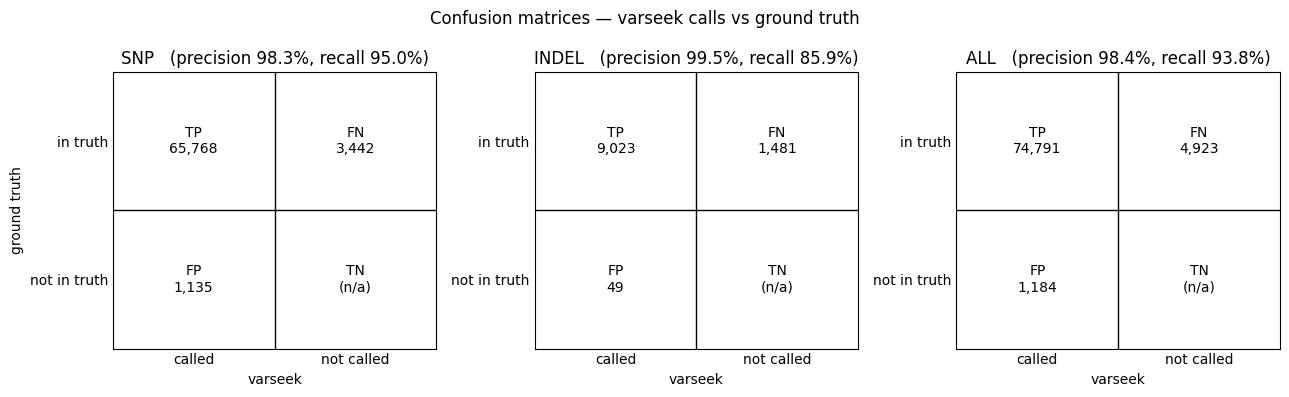

bcftools — confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=68,145   FP=2,615   FN= 1,065   precision=96.3%, recall=98.5%
  INDEL  TP= 9,592   FP=   86   FN=   912   precision=99.1%, recall=91.3%
  ALL    TP=77,737   FP=2,701   FN= 1,977   precision=96.6%, recall=97.5%


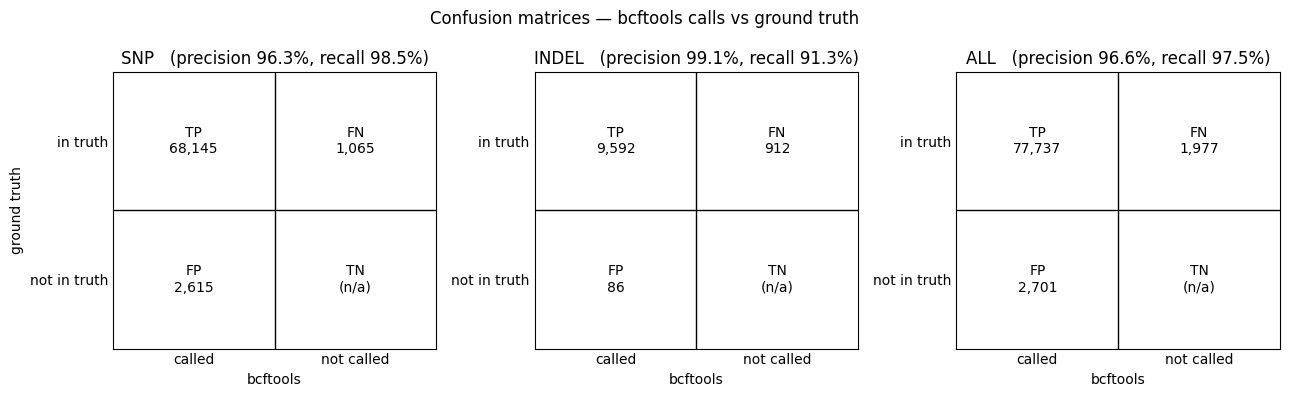

deepvariant — confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=67,115   FP=   98   FN= 2,095   precision=99.9%, recall=97.0%
  INDEL  TP=10,294   FP=   69   FN=   210   precision=99.3%, recall=98.0%
  ALL    TP=77,409   FP=  167   FN= 2,305   precision=99.8%, recall=97.1%


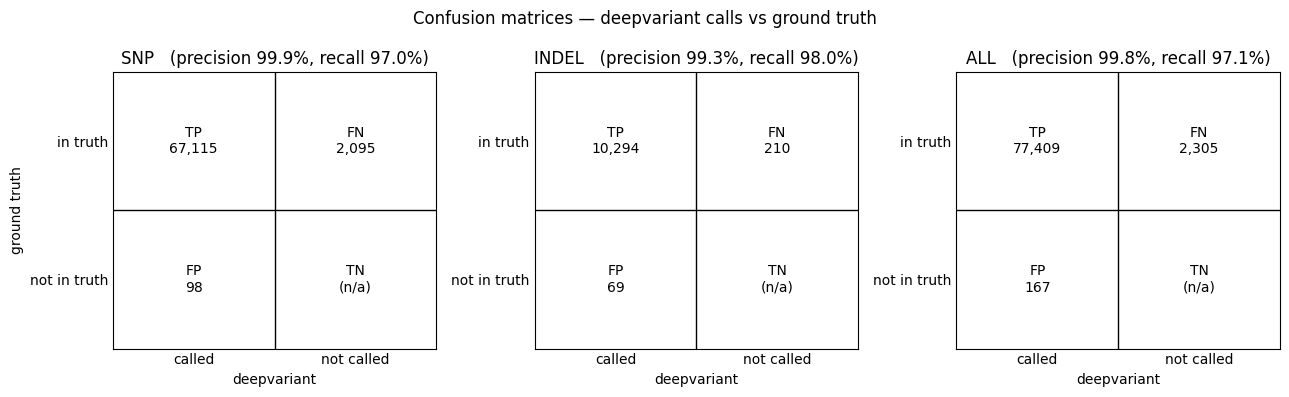

haplotypecaller — confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=67,584   FP=1,007   FN= 1,626   precision=98.5%, recall=97.7%
  INDEL  TP=10,317   FP=   84   FN=   187   precision=99.2%, recall=98.2%
  ALL    TP=77,901   FP=1,091   FN= 1,813   precision=98.6%, recall=97.7%


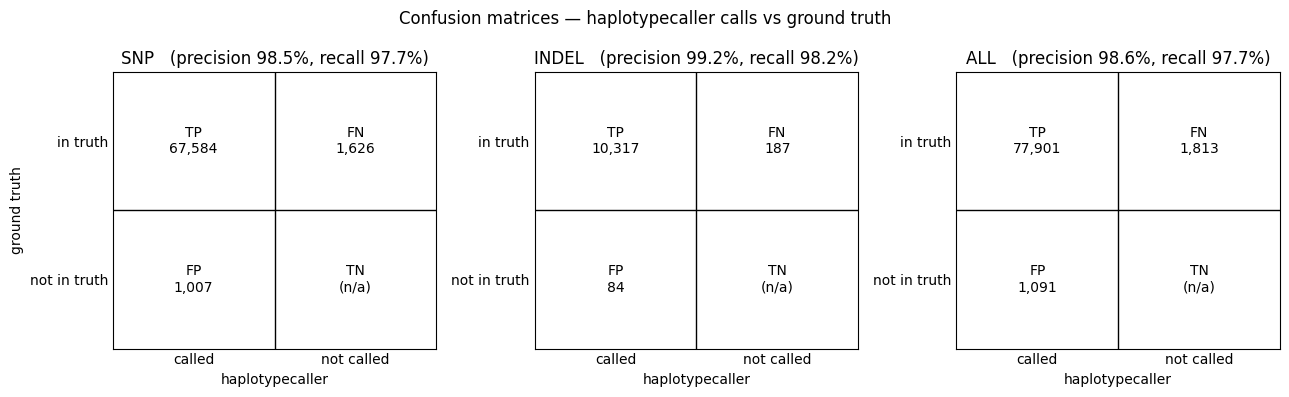

mutect2 — confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=56,656   FP=  452   FN=12,554   precision=99.2%, recall=81.9%
  INDEL  TP= 7,261   FP=    9   FN= 3,243   precision=99.9%, recall=69.1%
  ALL    TP=63,917   FP=  461   FN=15,797   precision=99.3%, recall=80.2%


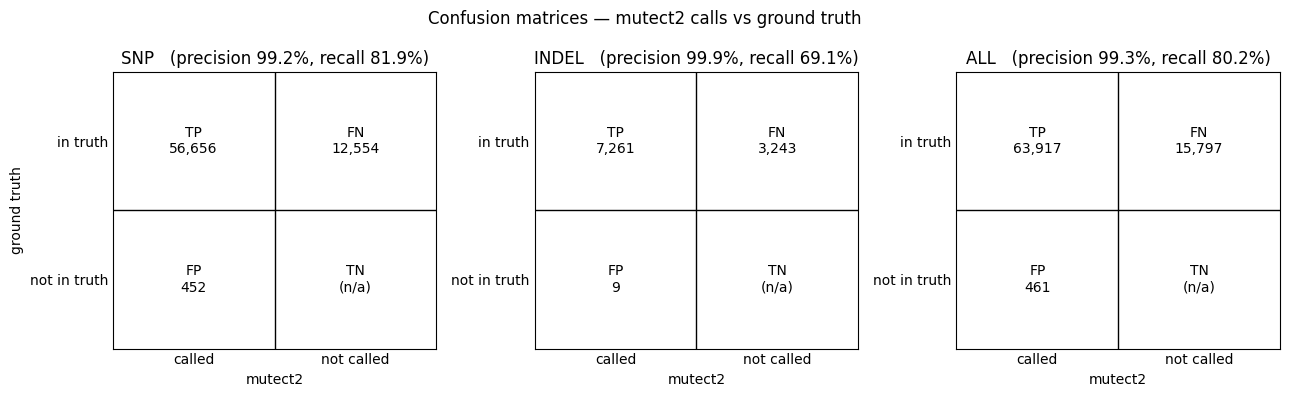

In [29]:
# --- one three-panel confusion matrix figure per caller ---------------------
all_cms = {}
for tool, summary_csv in happy_summaries.items():
    if not os.path.isfile(summary_csv):
        print(f"WARNING: no hap.py summary for {tool}; skipping.")
        continue
    all_cms[tool] = plot_confusion_matrices(summary_csv, tool=tool)

precision_%               recall_%                  F1        \
type                    ALL  INDEL    SNP      ALL  INDEL    SNP   ALL INDEL   
tool                                                                           
bcftools              96.64  99.11  96.30    97.52  91.32  98.46  0.97  0.95   
deepvariant           99.78  99.33  99.85    97.11  98.00  96.97  0.98  0.99   
haplotypecaller       98.62  99.19  98.53    97.73  98.22  97.65  0.98  0.99   
mutect2               99.28  99.88  99.21    80.18  69.13  81.86  0.89  0.82   
varseek               98.44  99.46  98.30    93.82  85.90  95.03  0.96  0.92   

                       
type              SNP  
tool                   
bcftools         0.97  
deepvariant      0.98  
haplotypecaller  0.98  
mutect2          0.90  
varseek          0.97

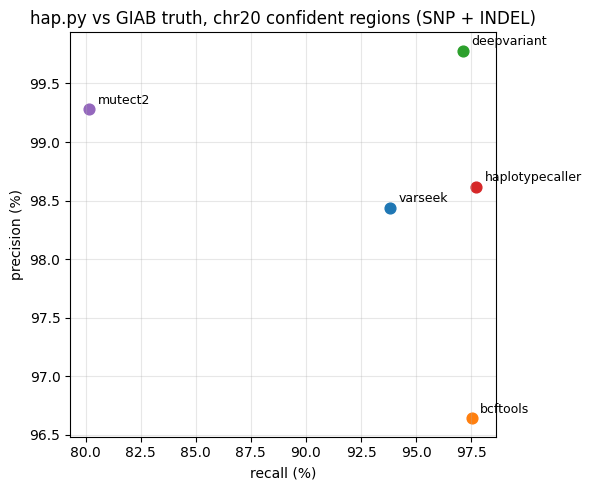

In [30]:
# --- side-by-side precision / recall / F1 across all callers ---------------
rows = []
for tool, cms in all_cms.items():
    for typ, (tp, fp, fn) in cms.items():
        prec, rec = tp / (tp + fp), tp / (tp + fn)
        rows.append({"tool": tool, "type": typ, "TP": tp, "FP": fp, "FN": fn,
                     "precision_%": round(100 * prec, 2), "recall_%": round(100 * rec, 2),
                     "F1": round(2 * prec * rec / (prec + rec), 4) if prec + rec else 0.0})
happy_all_tools = pd.DataFrame(rows)
display(happy_all_tools.pivot(index="tool", columns="type",
                              values=["precision_%", "recall_%", "F1"]).round(2))
happy_all_tools.to_csv(os.path.join(happy_out, "happy_all_tools_summary.csv"), index=False)

# precision-vs-recall scatter (ALL variant types), one point per caller
fig, ax = plt.subplots(figsize=(6, 5))
for tool in all_cms:
    r = happy_all_tools[(happy_all_tools.tool == tool) & (happy_all_tools.type == "ALL")].iloc[0]
    ax.scatter(r["recall_%"], r["precision_%"], s=60)
    ax.annotate(tool, (r["recall_%"], r["precision_%"]), textcoords="offset points",
                xytext=(6, 4), fontsize=9)
ax.set_xlabel("recall (%)"); ax.set_ylabel("precision (%)")
ax.set_title("hap.py vs GIAB truth, chr20 confident regions (SNP + INDEL)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Two optional precision filters: `remove_alignment_to_reference` (vk ref) × `pseudobam_validation` (vk count)

varseek exposes two independent filters that each trade recall for precision:

- **`remove_alignment_to_reference`** (in `vk ref`) — drops VCRSs whose variant k-mers also align to a normal reference (a d-list). Here we scope it to the **calling assembly, chr20** (`alignment_to_reference_dna=chr20.fa`), since the reads are chr20-only — the biologically correct scope (an off-chr20 paralog can't produce a read).
- **`pseudobam_validation`** (in `vk count`) — re-aligns every read with `kallisto quant --pseudobam` against the (chr20) reference genome and drops reads whose true genomic coordinate is inconsistent with the variant locus of the VCRS they were assigned to.

`run_varseek_workflow(remove_alignment_to_reference, pseudobam_validation)` below runs the **entire** `vk ref → vk count → adata→VCF → hap.py` pipeline for one setting. We run all four on/off combinations, **skipping any whose outputs already exist** — `(False, False)` is the main run from the top of the notebook (`happy_output/`). Then we compare recall vs precision across the four.

In [31]:
# =========================================================================
# Whole vk ref -> vk count -> hap.py workflow as one function, parameterized by
# the two precision filters. Every heavy step is guarded by output existence,
# so re-running is cheap and already-computed combinations are skipped.
# =========================================================================
project_root = os.getcwd()  # notebook root, where data/ and scripts/ live
root = os.path.join("data", "na12878_chr20", "varseek_parameter_tests")

def _run_happy(query_norm, happy_dir):
    summary = os.path.join(happy_dir, "varseek_vs_giab_truth.summary.csv")
    if os.path.isfile(summary):
        return summary
    os.makedirs(happy_dir, exist_ok=True)
    mounts = f"-v {project_root}:{project_root}"
    prefix = os.path.join(os.path.abspath(happy_dir), "varseek_vs_giab_truth")
    subprocess.run(
        f"podman run --rm {mounts} mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py "
        f"-r {os.path.abspath(sequences)} -f {os.path.abspath(confident_bed)} "
        f"--location 20 --threads {threads} --engine=scmp-somatic -o {prefix} "
        f"{os.path.abspath(truth_vcf)} {os.path.abspath(query_norm)}", shell=True, check=True)
    return summary

def run_varseek_workflow(remove_alignment_to_reference, pseudobam_validation):
    """vk ref -> vk count -> adata_to_vcf -> normalize -> hap.py; returns the hap.py summary path."""
    tag = f"rem{int(remove_alignment_to_reference)}_pb{int(pseudobam_validation)}"
    # (False, False) is the main run from the top of the notebook -> reuse its hap.py output
    if not remove_alignment_to_reference and not pseudobam_validation:
        return os.path.join(happy_out, "varseek_vs_giab_truth.summary.csv")

    ref_dir   = os.path.join(root, f"varseek_ref_out_{tag}")
    count_dir = os.path.join(root, f"varseek_count_out_{tag}")
    happy_dir = os.path.join(root, f"happy_output_{tag}")
    idx = os.path.join(ref_dir, "vcrs.idx"); t2g = os.path.join(ref_dir, "vcrs_t2g.txt")
    summary = os.path.join(happy_dir, "varseek_vs_giab_truth.summary.csv")
    if os.path.isfile(summary):
        print(f"[{tag}] outputs exist - skipping"); return summary
    os.makedirs(ref_dir, exist_ok=True)

    # 1) vk ref  (optionally d-list against the chr20 calling assembly)
    if not os.path.exists(idx):
        ref_kwargs = dict(variants=variants, sequences=sequences, seq_id_column="seq_id", var_column="variant",
                          remove_alignment_to_reference=remove_alignment_to_reference, species="human",
                          out=ref_dir, reference_out_dir=reference_dir,
                          index_out=idx, vcrs_t2g_out=t2g, w=w, k=k)
        vk.ref(**ref_kwargs)

    # 2) vk count  (optionally pseudobam-validate reads against the chr20 reference genome)
    if not os.path.exists(count_dir) or not os.path.exists(os.path.join(count_dir, "varseek_variants.vcf")):
        count_kwargs = dict(index=idx, t2g=t2g, technology="dna", parity="paired", out=count_dir,
                            k=k, threads=threads, strand="unstranded", min_counts=min_counts_clean)
        if pseudobam_validation:
            count_kwargs.update(pseudobam_validation=True, sequences=sequences,
                                reference_genome_index=os.path.join(giab_dir, "genome_kallisto_chr20.idx"),
                                reference_sequences_type="dna")
        res = vk.count([r1, r2], **count_kwargs)

    # 3) adata -> sites VCF -> normalize -> hap.py
    query_vcf = os.path.join(count_dir, "varseek_variants.vcf")
    if not os.path.exists(query_vcf):
        adata_to_vcf(res["adata_path"], query_vcf)
    query_norm = normalize_query(query_vcf, sequences)
    return _run_happy(query_norm, happy_dir)

# --- run all four combinations (skips any already computed) ---
combos = [(False, False), (True, False), (False, True), (True, True)]
combo_summaries = {}
for rem, pb in combos:
    combo_summaries[(rem, pb)] = run_varseek_workflow(rem, pb)
    print(f"remove_alignment_to_reference={rem!s:5s}  pseudobam_validation={pb!s:5s}  ->  {combo_summaries[(rem, pb)]}")

18:07:29 - INFO - Using COSMIC email from COSMIC_EMAIL environment variable
18:07:29 - INFO - Using COSMIC password from COSMIC_PASSWORD environment variable


remove_alignment_to_reference=False  pseudobam_validation=False  ->  data/na12878_chr20/happy_output/varseek_vs_giab_truth.summary.csv


18:07:54 - INFO - add_gene_name_to_header is set, but no GTF path was provided; leaving headers without gene-name annotations.
18:07:54 - INFO - Using the seq_id_column:var_column 'seq_id:variant' columns as the variant header column.
18:07:55 - INFO - Removing 0 duplications > k
/home/jrich/Desktop/varseek-fresh/varseek/varseek_build.py:1257: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutations["vcrs_sequence_kmer_length"] = mutations["vcrs_sequence"].apply(lambda x: len(x) if pd.notna(x) else 0)
18:07:59 - INFO - Removed 108 variant-containing reference sequences with length less than 41...
18:07:59 - INFO - Removed 0 variant-containing reference sequences containing more than 0 'N's...
18:07:59 - INFO - Running bowtie2 alignment
Scanning bo

Wrote 35,431 variants to data/na12878_chr20/varseek_parameter_tests/varseek_count_out_rem1_pb0/varseek_variants.vcf


Writing to /home/jrich/tmp/bcftools.ysngSw
Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	35431/0/0/0/0/0/0
Merging 1 temporary files
Done
Cleaning
2026-07-19 01:10:41,410 WARNING  No reference file found at default locations. You can set the environment variable 'HGREF' or 'HG19' to point to a suitable Fasta file.
[I] Total VCF records:         83629
[I] Non-reference VCF records: 83629
[W] overlapping records at 20:4274925 for sample 0
[W] Variants that overlap on the reference allele: 12
[I] Total VCF records:         35431
[I] Non-reference VCF records: 35431


...

remove_alignment_to_reference=False  pseudobam_validation=True   ->  data/na12878_chr20/varseek_parameter_tests/happy_output_rem0_pb1/varseek_vs_giab_truth.summary.csv


18:38:51 - INFO - add_gene_name_to_header is set, but no GTF path was provided; leaving headers without gene-name annotations.
18:38:51 - INFO - Using the seq_id_column:var_column 'seq_id:variant' columns as the variant header column.
18:38:52 - INFO - Removing 0 duplications > k
/home/jrich/Desktop/varseek-fresh/varseek/varseek_build.py:1257: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutations["vcrs_sequence_kmer_length"] = mutations["vcrs_sequence"].apply(lambda x: len(x) if pd.notna(x) else 0)
18:38:55 - INFO - Removed 108 variant-containing reference sequences with length less than 41...
18:38:56 - INFO - Removed 0 variant-containing reference sequences containing more than 0 'N's...
18:38:56 - INFO - Running bowtie2 alignment
Scanning bo

Wrote 35,451 variants to data/na12878_chr20/varseek_parameter_tests/varseek_count_out_rem1_pb1/varseek_variants.vcf


Writing to /home/jrich/tmp/bcftools.hvKLQ6
Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	35451/0/0/0/0/0/0
Merging 1 temporary files
Done
Cleaning
2026-07-19 02:05:08,647 WARNING  No reference file found at default locations. You can set the environment variable 'HGREF' or 'HG19' to point to a suitable Fasta file.
[I] Total VCF records:         83629
[I] Non-reference VCF records: 83629
[W] overlapping records at 20:4274925 for sample 0
[W] Variants that overlap on the reference allele: 12
[I] Total VCF records:         35451
[I] Non-reference VCF records: 35451


Hap.py v0.3.12
Benchmarking Summary:
Type Filter  TRUTH.TOTAL  TRUTH.TP  TRUTH.FN  QUERY.TOTAL  QUERY.FP  QUERY.UNK  FP.gt  FP.al  METRIC.Recall  METRIC.Precision  METRIC.Frac_NA  METRIC.F1_Score  TRUTH.TOTAL.TiTv_ratio  QUERY.TOTAL.TiTv_ratio  TRUTH.TOTAL.het_hom_ratio  QUERY.TOTAL.het_hom_ratio
INDEL    ALL        10504      4277      6227         4278        16          0      0      0       0.407178          0.996260             0.0         0.578088                     NaN                     NaN                        NaN                        NaN
INDEL   PASS        10504      4277      6227         4278        16          0      0      0       0.407178          0.996260             0.0         0.578088                     NaN                     NaN                        NaN                        NaN
  SNP    ALL        69210     30695     38515        31173       463          0      0      0       0.443505          0.985147             0.0         0.611651                2.2

,remove_alignment,pseudobam,combo,type,TP,FP,recall_%,precision_%,F1
0,False,False,base\n(no filters),SNP,65768,1135,95.03,98.30,0.9664
1,False,False,base\n(no filters),INDEL,9023,49,85.90,99.46,0.9218
2,True,False,d-list\nonly,SNP,30674,464,44.32,98.51,0.6114
3,True,False,d-list\nonly,INDEL,4277,16,40.72,99.63,0.5781
4,False,True,pseudobam\nonly,SNP,65850,934,95.15,98.60,0.9684
5,False,True,pseudobam\nonly,INDEL,9038,42,86.04,99.54,0.9230
6,True,True,both filters,SNP,30695,463,44.35,98.51,0.6117
7,True,True,both filters,INDEL,4277,16,40.72,99.63,0.5781


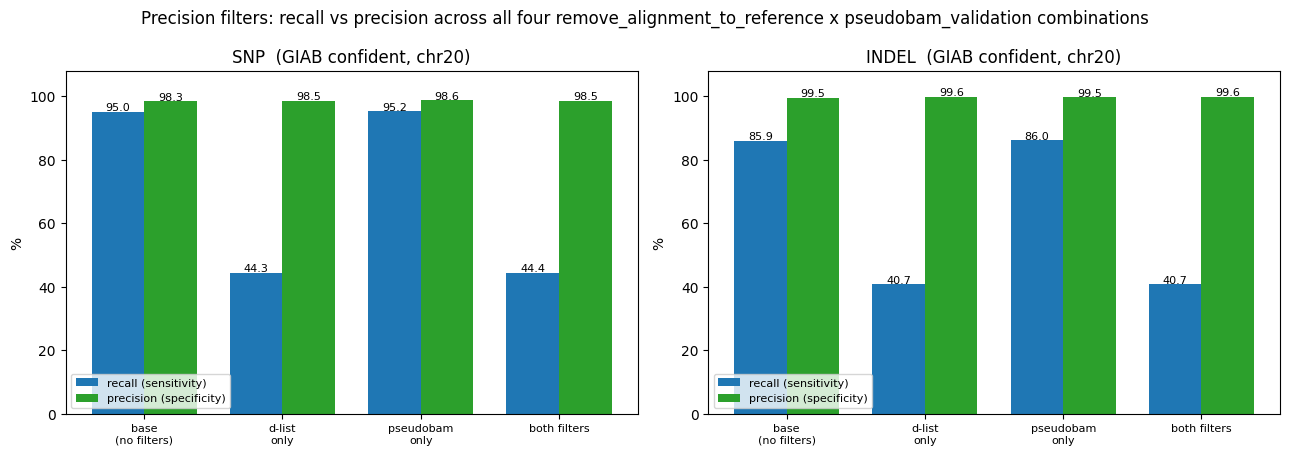

Saved data/na12878_chr20/happy_output/precision_filter_combinations.png


In [32]:
# --- compare recall vs precision across the four filter combinations ---
import matplotlib.pyplot as plt

COMBO_LABELS = {(False, False): "base\n(no filters)", (True, False): "d-list\nonly",
                (False, True): "pseudobam\nonly", (True, True): "both filters"}
order = [(False, False), (True, False), (False, True), (True, True)]

rows = []
for combo in order:
    s = pd.read_csv(combo_summaries[combo])
    s = s[s["Filter"] == "PASS"].set_index("Type")
    for typ in ["SNP", "INDEL"]:
        r = s.loc[typ]
        rows.append({"remove_alignment": combo[0], "pseudobam": combo[1], "combo": COMBO_LABELS[combo],
                     "type": typ, "TP": int(r["TRUTH.TP"]), "FP": int(r["QUERY.FP"]),
                     "recall_%": round(100 * r["METRIC.Recall"], 2),
                     "precision_%": round(100 * r["METRIC.Precision"], 2),
                     "F1": round(r["METRIC.F1_Score"], 4)})
combo_df = pd.DataFrame(rows)
display(combo_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
labels = [COMBO_LABELS[c] for c in order]
for ax, typ in zip(axes, ["SNP", "INDEL"]):
    sub = combo_df[combo_df["type"] == typ].set_index("combo").loc[labels]
    x, wdt = np.arange(len(labels)), 0.38
    ax.bar(x - wdt/2, sub["recall_%"],    wdt, label="recall (sensitivity)",    color="#1f77b4")
    ax.bar(x + wdt/2, sub["precision_%"], wdt, label="precision (specificity)", color="#2ca02c")
    for xi, (rc, pr) in enumerate(zip(sub["recall_%"], sub["precision_%"])):
        ax.text(xi - wdt/2, rc + 0.5, f"{rc:.1f}", ha="center", fontsize=8)
        ax.text(xi + wdt/2, pr + 0.5, f"{pr:.1f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f"{typ}  (GIAB confident, chr20)"); ax.set_ylabel("%"); ax.set_ylim(0, 108)
    ax.legend(loc="lower left", fontsize=8)
fig.suptitle("Precision filters: recall vs precision across all four "
             "remove_alignment_to_reference x pseudobam_validation combinations")
fig.tight_layout()
combo_png = os.path.join(happy_out, "precision_filter_combinations.png")
fig.savefig(combo_png, dpi=150, bbox_inches="tight"); plt.show()
print("Saved", combo_png)

### Tool runtimes

Wall-clock runtime for each caller, read back from `tool_runtimes.json`. The three
varseek stages (`vk denovo`, `vk ref`, `vk count`) are recorded separately in the JSON
but summed into a single **varseek** bar (shown stacked so the per-stage breakdown is
still visible). Any tool that was skipped on this run (output already existed) keeps its
previously recorded time.

Recorded runtimes:
  vk denovo          1009.9 s  ( 16.83 min)
  vk ref               99.1 s  (  1.65 min)
  vk count             73.5 s  (  1.22 min)
  haplotypecaller    1727.5 s  ( 28.79 min)
  mutect2            1306.7 s  ( 21.78 min)
  deepvariant         941.6 s  ( 15.69 min)
  varseek (total)    1182.5 s  ( 19.71 min)
Saved plot -> data/na12878_chr20/varseek_parameter_tests/tool_runtimes.png


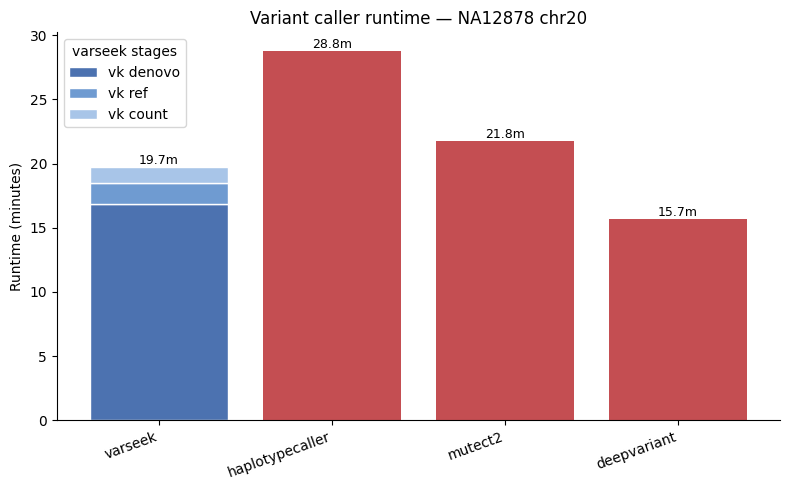

In [33]:
import matplotlib.pyplot as plt

rt = load_runtimes()

varseek_stages = ["vk denovo", "vk ref", "vk count"]
other_tools = ["haplotypecaller", "mutect2", "deepvariant", "vartrix"]

print("Recorded runtimes:")
for name in varseek_stages + other_tools:
    if name in rt:
        print(f"  {name:16s} {rt[name]:8.1f} s  ({rt[name]/60:6.2f} min)")
varseek_total = sum(rt.get(s, 0.0) for s in varseek_stages)
print(f"  {'varseek (total)':16s} {varseek_total:8.1f} s  ({varseek_total/60:6.2f} min)")

# --- build bars: one stacked varseek bar + one bar per other tool present ----
present_others = [(t, rt[t]) for t in other_tools if t in rt]
stage_vals = [rt.get(s, 0.0) for s in varseek_stages]

fig, ax = plt.subplots(figsize=(8, 5))
labels = ["varseek"] + [t for t, _ in present_others]
x = list(range(len(labels)))

# stacked varseek bar (per-stage segments)
stage_colors = ["#4C72B0", "#6f9bd1", "#a8c5e8"]
bottom = 0.0
for val, stage, c in zip(stage_vals, varseek_stages, stage_colors):
    ax.bar(0, val / 60, bottom=bottom / 60, color=c, edgecolor="white", label=stage)
    bottom += val

# other tools
for i, (t, v) in enumerate(present_others, start=1):
    ax.bar(i, v / 60, color="#C44E52")

# annotate totals on top of each bar
totals = [varseek_total] + [v for _, v in present_others]
for xi, tot in zip(x, totals):
    ax.text(xi, tot / 60, f"{tot/60:.1f}m", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Runtime (minutes)")
ax.set_title("Variant caller runtime — NA12878 chr20")
ax.legend(title="varseek stages", loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

runtime_plot_png = os.path.join(root, "tool_runtimes.png")
plt.savefig(runtime_plot_png, dpi=150)
print(f"Saved plot -> {runtime_plot_png}")
plt.show()